# Coursework 1
**Replace CID in the file name with your CID**

# Outline


- [Task 1](#task-1): Linear regression and feature selection <a name="index-task-1"></a>
  - [(1.1)](#task-11) <a name="index-task-11"></a>
  - [(1.2)](#task-12) <a name="index-task-12"></a>
  - [(1.3)](#task-13) <a name="index-task-13"></a>
  - [(1.4)](#task-14) <a name="index-task-14"></a>
- [Task 2](#task-2): Non-linear regression with Kernel Ridge Regression <a name="index-task-2"></a>
  - [(2.1)](#task-21) <a name="index-task-21"></a>
  - [(2.2)](#task-22)  <a name="index-task-22"></a>
- [Task 3](#task-3): Classification with the Multi-Layer Perceptron <a name="index-task-3"></a>
  - [(3.1)](#task-31) <a name="index-task-31"></a>
  - [(3.2)](#task-32)  <a name="index-task-32"></a>



---



<a name="task-1"></a>

# Task 1: Linear regression and feature selection [(index)](#index-task-1)

<a name="task-11"></a>

## (1.1) [(index)](#index-task-11)

**Data Processing**

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm

SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# fixing random generator for reproducibility
rng = np.random.default_rng(0)

In [2]:
df_train = pd.read_csv('asteroid_observations_train.csv')
df_test = pd.read_csv('asteroid_observations_test.csv')
df_train.head()

,Absolute magnitude,Albedo,Number of observations,Observation arc length,Orbital eccentricity,Orbital inclination,Orbital period,Asteroid diameter,Asteroid class
0,18.1,0.041,15,2.0,0.201590,11.975800,3.912298,1.573,MBA
1,12.5,0.139,349,7208.0,0.032746,8.793883,11.942668,12.355,TJN
2,14.1,0.062,705,25309.0,0.179314,27.433960,5.749452,8.862,OMB
3,16.9,0.097,91,3805.0,0.066114,13.813845,4.592982,2.139,MBA
4,11.5,0.062,1300,9606.0,0.008824,5.595907,12.006096,30.763,TJN


In [3]:
features = ['Absolute magnitude', 'Albedo', 'Number of observations', 
            'Observation arc length', 'Orbital eccentricity', 
            'Orbital inclination', 'Orbital period']
target = 'Asteroid diameter'

X_train = df_train[features].values
y_train = df_train[target].values.reshape(-1, 1)

X_test = df_test[features].values
y_test = df_test[target].values.reshape(-1, 1)

In [4]:
def standardise(X, X_train_=None):
    """
    Standardise features.

    Args:
        X (np.array): Feature matrix.
        X_train_ (np.array): An optional feature matrix to compute the statistics
            from before applying it to X. If None, just use X to compute the statistics.

    Returns:
        X_std (np.array): Standardised feature matrix
    """
    if X_train_ is None:
        X_train_ = X

    mu = np.mean(X_train_, axis=0, keepdims=True)
    sigma = np.std(X_train_, axis=0, keepdims=True)
    X_std = (X - mu) / sigma

    return X_std

In [5]:
# We standardise both training and test sets
X_train_std = standardise(X_train)
X_test_std = standardise(X_test, X_train)

# Insert 1 in every row for intercept b
X_train_intercept = np.hstack((np.ones((len(X_train_std), 1)), X_train_std))
X_test_intercept = np.hstack((np.ones((len(X_test_std), 1)), X_test_std))

**Ordinary Linear Regression**

In [6]:
def max_lik_estimate(X, y):
    """
    Compute the maximum likelihood estimate for linear regression parameters.
    Args:
        X: N x p matrix of training inputs
        y: N x 1 vector of training targets/observations

    returns: 
        beta_ml: maximum likelihood parameters (p x 1)
    """

    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    beta_ml = np.linalg.solve(X.T @ X, X.T @ y)
    return beta_ml

In [7]:
# get maximum likelihood estimate
beta_ml = max_lik_estimate(X_train_intercept,y_train)
beta_ml

array([[11.83155799],
       [-9.25892809],
       [-3.11707348],
       [ 1.99398808],
       [ 1.37607063],
       [ 0.34068455],
       [ 0.97216587],
       [-0.30875842]])

**Linear Regression with Garrote**

In Garrote, the predicted values are given by $\hat{y}=f_{\boldsymbol{\beta}^G, \hat{\beta}_0^{LS}}(\boldsymbol{x})=\sum_{i=1}^p g_j \hat{\beta}^{LS}_j x_j + \hat{\beta}^{LS}_0$. This can be written into the vector form:
$$
\boldsymbol{\hat{y}} = \boldsymbol{X_{std}} diag(\hat{\beta}_1^{LS}, ..., \hat{\beta}_p^{LS}) \boldsymbol{g} + \boldsymbol{\hat{\beta}_0^{LS}}
$$
where $\boldsymbol{\hat{\beta}_0^{LS}} = (\hat{\beta}_0^{LS}, ..., \hat{\beta}_0^{LS})^T$.

The Garrote parameters $\boldsymbol{g}=(g_1, ..., g_p)^T$ are learnt by minimising a loss given by the mean square error (MSE) over the training set : $$\min_{\boldsymbol{g}} \left[ \frac{1}{N^{\text{train}}} \sum_{i=1}^{N^{\text{train}}} \left( y^{(i)} - f_{\boldsymbol{\beta}^G, \hat{\beta}_0^{LS}}(\boldsymbol{x}^{(i)}) \right)^2 \right]$$
under the constraint:
$$
\|\boldsymbol{g}\|_1 = \sum_{j=1}^{p} |g_j| < s \quad \text{for some } s \in \mathbb{R}_{\ge 0}
$$

This is equivalent to minimize the following loss:
$$
L_\text{Garrote}(\boldsymbol{g}) = \frac{1}{N^{\text{train}}} || \boldsymbol{y} - \boldsymbol{\hat{y}}||^2 + \lambda ||\boldsymbol{g}||_1.
$$.

where $
|| \boldsymbol{y} - \boldsymbol{\hat{y}}||^2
= || \boldsymbol{y} - \boldsymbol{X_{std}} diag(\hat{\beta}_1^{LS}, ..., \hat{\beta}_p^{LS}) \boldsymbol{g} - \boldsymbol{\hat{\beta}_0^{LS}}||^2.
$

Let $\boldsymbol{y'} = \boldsymbol{y} - \boldsymbol{\hat{\beta}_0^{LS}}$ and $\boldsymbol{Z}=\boldsymbol{X_{std}} diag(\hat{\beta}_1^{LS}, ..., \hat{\beta}_p^{LS})$, so $|| \boldsymbol{y} - \boldsymbol{\hat{y}}||^2=||\boldsymbol{y'} - \boldsymbol{Z} \boldsymbol{g}||^2 = (\boldsymbol{y'} - \boldsymbol{Z} \boldsymbol{g})^T(\boldsymbol{y'} - \boldsymbol{Z} \boldsymbol{g})$.

Also, we can replace $||\boldsymbol{g}||_1$ with the Huber Loss $\sum_{i=1}^p L_c(g_i)$, where $L_c(g_i)$ is defined as:

$L_c (g_i) =
\begin{cases}
 \frac{1}{2}{g^2_i}                   & \text{for } |g_i| \le c, \\
 c (|g_i| - \frac{1}{2}c), & \text{otherwise,}
\end{cases}
$

for $i=1,\ldots,p$.

The piecewise smooth function $L_c (g_i)$ has the gradient:

$\frac{dL_c (g_i)}{dg_i} =
  \begin{cases}
 g_i                   & \text{for } |g_i| \le c, \\
 c\, \text{sign}(g_i) , & \text{otherwise,}
\end{cases}
$

for $i=1,\ldots,p$.

Now we can minimise the following relaxed function by gradient descent:

$
\begin{align} L_\text{Garrote-Huber}(\boldsymbol{g})
&= \frac{1}{N^{\text{train}}} || \boldsymbol{y'} - \boldsymbol{Z} \boldsymbol{g}||^2 + \lambda \sum_{i=1}^p L_c(g_i) \\
&= \frac{1}{N^{\text{train}}} (\boldsymbol{y'} - \boldsymbol{Z} \boldsymbol{g})^T(\boldsymbol{y'} - \boldsymbol{Z} \boldsymbol{g})  + \lambda \sum_{i=1}^p L_c(\beta_i) \\
&= \frac{1}{N^{\text{train}}} \left(\boldsymbol{y'}^T\boldsymbol{y'} - \boldsymbol{y'}^T\boldsymbol{Z}\boldsymbol{g} - \boldsymbol{g}^T\boldsymbol{Z}^T  \boldsymbol{y'} + \boldsymbol{g}^T\boldsymbol{Z}^T\boldsymbol{Z}\boldsymbol{g}\right) + \lambda \sum_{i=1}^p L_c(g_i)
\end{align}
$

Which has the gradient:

$
\begin{align} \nabla_{\boldsymbol{g}} L_\text{Garrote-Huber}
&= \frac{2}{N^{\text{train}}}\left(\boldsymbol{Z}^T\boldsymbol{Z}\boldsymbol{g} - \boldsymbol{Z}^T\boldsymbol{y'}\right) + \lambda \nabla_{\boldsymbol{g}}L_c(\boldsymbol{g})
\end{align}$

We next implement gradient-descent to solve the optimisation for the Garrote model. At the  iteration $t+1$ the parameters are updated according to:
$$
\boldsymbol g_{t+1} = \boldsymbol g_t - \eta_t \nabla_{\boldsymbol g} L(\boldsymbol g_t)
$$
where $\eta_t$ is the step size.

In [8]:
# huber loss
def huber(g, c = 1e-4):
    return np.where(np.abs(g) < c, (g**2)/2.,c * (np.abs(g) - c/2))

# gradient of huber loss
def grad_huber(g, c = 1e-4):
    return  np.where(np.abs(g) < c, g, c * np.sign(g))

In [9]:
def minimize_garrote_huber(X, y, beta, lambd, n_iters = 10000, step_size=5e-5, c_huber=1e-4):
    """
    This function estimates the regression parameters with the relaxed version
    of Garrote regression using the gradient-descent algorithm to find the optimal
    solution.
    Args:
        X (np.array): The standardised data matrix with shape (N, p).
        y (np.array): The response column with shape (N, 1).
        beta (np.array): The ordinary least squares parameters with shape (p+1, 1).
        lambd (float): The multiplier of the relaxed L1 term.
        n_iters (int): Number of gradient descent iterations.
        step_size (float): The step size in the updating step.
        c_huber (float): The threshold parameter for the Huber loss.

    Returns:
        g (np.array): The estimated parameters for the relaxed Garrote regression with shape (p, 1).
    """

    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    # Precomputed products to avoid redundant computations.
    y_dash = y - beta[0]
    Z = X * beta[1:].T
    ZZ = Z.T @ Z
    Zy = Z.T @ y_dash
    # Initialize g params with zero
    g = np.zeros((p, 1))

    for i in range(n_iters):
        # Compute the gradient of the relaxed Garrote, Huber.
        grad_c = grad_huber(g, c=c_huber)

        # Compute the gradient of the regularised loss.
        grad = (2*(ZZ @ g - Zy)/N) + lambd * grad_c

        # Update g
        g = g - step_size * grad

        

    return g

Study the effect of penalty term $\lambda$

In [10]:
def garrote_coefficient_trajectories(lambdas, X_std, y, beta):
    """
    Computes the trajectories of the Garrote coeffiencts for a list of lambdas.
    Args:
        lambdas (list of float): A list of lambda values.
        X_std (np.array): The standardised data matrix with shape (N, p).
        y (np.array): The response column with shape (N, 1).
        beta (np.array): The ordinary least squares parameters with shape (p+1, 1).
    Returns:
        coeff_trajectories (np.array)
    """
    # initialise trajectories
    coeff_trajectories = []
    for lam in lambdas:
        # Run Garrote regression
        g = minimize_garrote_huber(X_std, y, beta, lambd=lam, n_iters=10000,
                                        step_size=1e-7,
                                        c_huber=1e-4)
        beta_garrote = beta[1:] * g
        beta_garrote = beta_garrote.flatten()

        coeff_trajectories.append(beta_garrote)
    return np.vstack(coeff_trajectories)

In [11]:
lambdas = np.logspace(-1, 7.6, 15)

coeffs_g = garrote_coefficient_trajectories(lambdas, X_train_std, y_train, beta_ml)
print(coeffs_g.shape)

(15, 7)


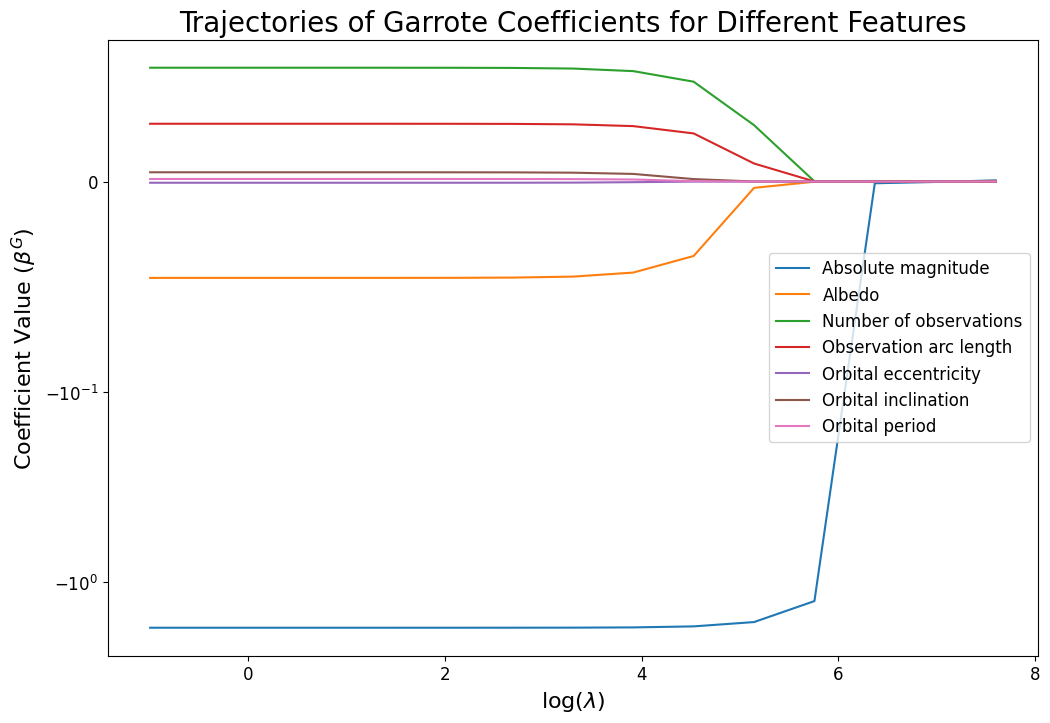

In [12]:
# plot the trajectores of Garrote coefficients using log-scale
plt.figure(figsize=(12, 8))
for i in range(coeffs_g.shape[1]):
    plt.plot(np.log10(lambdas), coeffs_g[:, i], label=features[i])

plt.yscale("symlog", linthresh=0.1)
plt.xlabel(r'log($\lambda$)')
plt.ylabel(r'Coefficient Value ($\beta^G$)')
plt.title('Trajectories of Garrote Coefficients for Different Features')
plt.legend()
plt.show()

### Discussion: 
The trajectory plot demonstrates that the Garrote method effectively performs feature selection by driving coefficients to exactly zero as regularization strength $\lambda$ increases, yielding a sparse and interpretable model. This plot shows that the features "orbital periods", "orbital eccentricity" and "orbital inclination" are insignificant since their $\beta^G$ are always almost zero throughout the different values of $\lambda$. The feature "absolute magnitude" is the most dominant predictor for it has the greatest absolute value of $\beta^G$. The "numbder of observations", "albedo" and "observation arc length" are also robust features since their $\beta^G$ do not go to zero as quickly as "orbital periods", "orbital eccentricity" and "orbital inclination".

The feature selection performs well even when $\lambda = 10^4$ as there is little shrinkage of each coefficient. As $\lambda$ increases to a very large value ($\lambda$ > $10^6$), all coefficients are forced to become 0. This shows Garrote's effectiveness to encourage sparsity and shrinkage of features.

<a name="task-12"></a>

## (1.2) [(index)](#index-task-12)

**MSE Computation**

Firstly, we split the data $S={\boldsymbol{x}^{(i), y^{(i)}}}$ for $i = 1, ..., N^{training}$ into $T$ equal subsets $S_t$ such that:
$$ S = \bigcup_{t=1}^{T} S_t \quad \text{and} \quad |S_t| = \frac{|S|}{T}, \quad \text{where} \quad |S| = N^{\text{training}} $$
Then we train the model on $\overline{S}_t = S - S_t$ to get $\hat{f}_{\overline{S}_t}(\mathbf{x}^{(i)})$ and use the validation set $S_t$ to compute 
$$
\text{MSE}_t = \frac{1}{|S_t|} \sum_{i \in S_t} \left[ \hat{f}_{\overline{S}_t}(\mathbf{x}^{(i)}) - y^{(i)} \right]^2
$$
Finally we can compute average absolute difference in the validation MSE between successive folds D:
$$
D = \frac{1}{T-1} \sum_{t=2}^{T} \left| \text{MSE}_t - \text{MSE}_{t-1} \right|
$$

**T-fold split**

In [13]:
def cross_val_split(num_samples, num_folds):
    """
    Splits the dataset indices into `num_folds` folds for cross-validation.

    Args:
        num_samples (int): The total number of samples in the dataset.
        num_folds (int): The number of folds for cross-validation.

    Returns:
        fold (list[np.array]): A list of numpy arrays containing the indices defining the validation set for one fold.
    """

    fold_size = num_samples // num_folds
    indices = np.arange(num_samples)
    
    folds = [
        indices[k * fold_size : (k + 1) * fold_size]
        for k in range(num_folds)
    ]
    
    return folds

**Compute average absolute difference in the validation MSE between successive folds D by Cross Validation**

In [14]:
def cross_val_evaluate(X, y, num_folds, lambdas):
    """
    Performs T-fold cross-validation on the given dataset to find the optimal regul_strength.

    Args:
        X (np.array): Input features.
        y (np.array): Output target.
        num_folds (int): The number of folds for cross-validation.
        lambdas (list): A list of regularisation strength values to evaluate.

    Returns:
        D: average absolute difference in the validation MSE between successive folds
    """

    num_samples = X.shape[0]
    folds = cross_val_split(num_samples, num_folds)
    mse = np.zeros(num_folds)
    D = np.zeros(len(lambdas))

    for j, lam in enumerate(lambdas):

        # T-fold cross validation
        for i, val_indices in enumerate(folds):

            # Define the training and validation sets
            train_indices = np.setdiff1d(np.arange(num_samples), val_indices)
            X_train, y_train = X[train_indices], y[train_indices]
            X_val, y_val = X[val_indices], y[val_indices]

            # We standardise both training and validation sets
            X_train_std = standardise(X_train)
            X_val_std = standardise(X_val, X_train)

            # Insert 1 in every row for intercept b
            X_train_intercept = np.hstack((np.ones((len(X_train_std), 1)), X_train_std))

            # Compute ordinary least squares estimate for initialisation
            beta_ml = max_lik_estimate(X_train_intercept, y_train)

            # Train the model using Garrote regression
            g = minimize_garrote_huber(X_train_std, y_train, beta_ml, lambd=lam, n_iters=10000,
                                        step_size=1e-7,
                                        c_huber=1e-4)
            beta_garrote = beta_ml[1:] * g
            y_pred = X_val_std @ beta_garrote + beta_ml[0]

            # Compute the MSE
            mse[i] = np.mean((y_val - y_pred)**2)

        # Compute D for each lambda
        D[j] = np.mean(np.abs(mse[1:] - mse[:-1]))

    return D

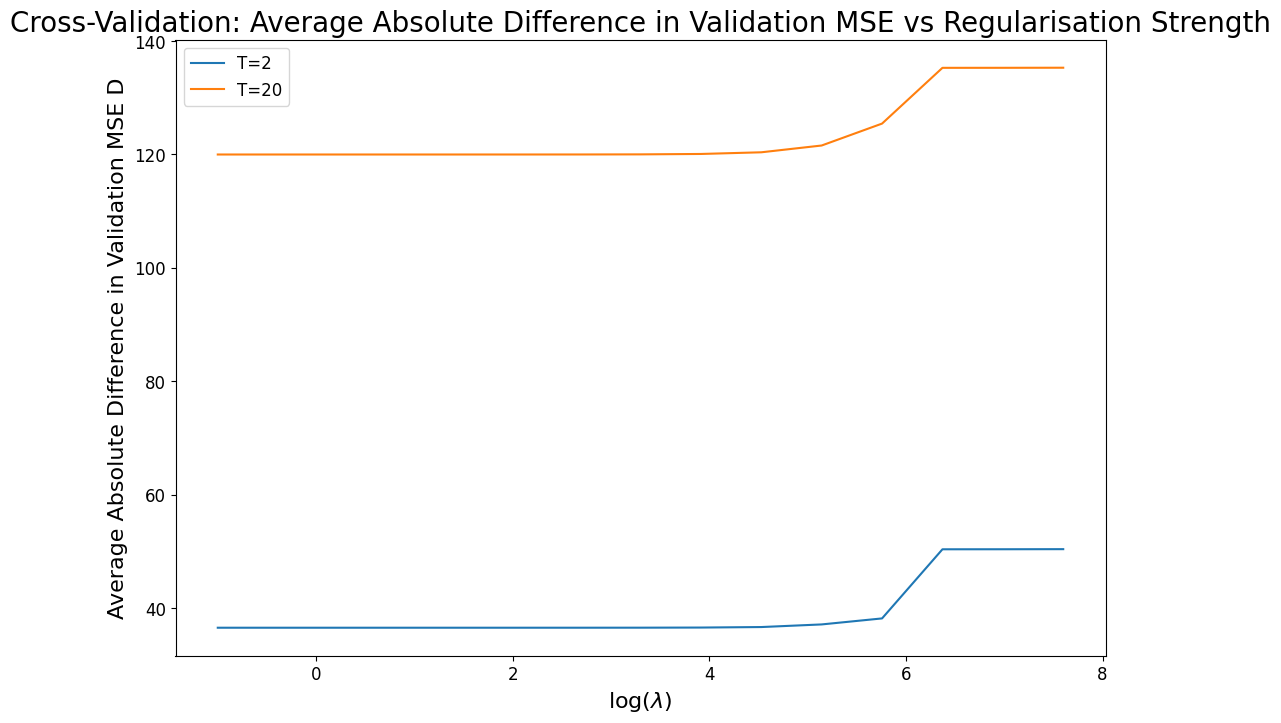

In [15]:
# Plot D against log(lambda) for T=2 and T=20
plt.figure(figsize=(12, 8))
for T in [2, 20]:
    D = cross_val_evaluate(X_train, y_train, T, lambdas)
    plt.plot(np.log10(lambdas), D, label=f'T={T}')

plt.xlabel(r'log($\lambda$)')
plt.ylabel('Average Absolute Difference in Validation MSE D')
plt.title('Cross-Validation: Average Absolute Difference in Validation MSE vs Regularisation Strength')
plt.legend()
plt.show()


### Discussion:

When $\lambda$ is small ($log(\lambda)<5$), both $D$ of $T=2$ and $T=20$ remains relatively constant and low, suggesting that the Garrote predictor is stable when the regularization is weak to moderate. However, as $\lambda$ increases beyond $10^5$, there is a sharp increase in $D$, indicating a decrease in stability. This behavior likely occurs because the high $\lambda$ values force the model to underfit significantly, shrinking coefficients towards 0. This makes the model fails to utilise the feature values and the validation $MSE$ only depends on the inherent variance and noise of the target value $y_{true}$ in each specific fold, which fluctuates randomly between folds, so $D$ stays relatively high and constant when $log(\lambda)>6$, and the Garrote predictor is not as stable as before.

There is a significant magnitude difference between the two curves, with $T=20$ exhibiting a much higher average absolute difference $D$ compared to $T=2$. This discrepancy is primarily due to the size of the validation sets used to compute the MSE. For $T=2$, the validation set consists of 50% of the data. This large sample size dilutes the effect of noise and outliers, resulting in a robust and stable estimate of the MSE across folds. For $T=20$, the validation set has a much smaller sample size (5% of the data), so the MSE is highly sensitive to the specific data points included in that fold. A single outlier can cause a rise in the $MSE$ for one fold, leading to large differences when compared to the next fold.

<a name="task-13"></a>

## (1.3) [(index)](#index-task-13)

To implement LASSO, we can adapt the code from week 1 $\texttt{Linear regression.ipynb}$ directly.

In [16]:
# LASSO Huber minimization
def minimize_LASSO_huber(X, y, lambd, n_iters = 10000, step_size=1e-7, c_huber=1e-4):
    """
    This function estimates the regression parameters with the relaxed version
    of LASSO regression using the gradient-descent algorithm to find the optimal
    solution.
    Args:
    X (np.array): The augmented data matrix with shape (N, p + 1).
    y (np.array): The response column with shape (N, 1).
    lambd (float): The multiplier of the relaxed L1 term.
    n_iters (int): Number of gradient descent iterations.
    step_size (float): The step size in the updating step.
    """

    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    # Precomputed products to avoid redundant computations.
    XX = X.T @ X
    Xy = X.T @ y
    # Initialize beta params with zeros
    beta = np.zeros((p,1))

    for i in range(n_iters):
        # Compute the gradient of the relaxed LASSO, Huber.
        grad_c = grad_huber(beta, c=c_huber)

        # Intercept term is not involved in the regularisation.
        grad_c[0] = 0

        # Compute the gradient of the regularised loss.
        grad = (2*(XX @ beta - Xy)/N) + lambd * grad_c

        # Update beta
        beta = beta - step_size * grad

    return beta

In [17]:
def lasso_coefficient_trajectories(lambdas, X_aug, y):
    """Computes the trajectories of the LASSO coeffiencts for a list of lambdas.
    """
    # initialise trajectories
    coeff_trajectories = []
    for lam in lambdas:
        # Run LASSO regression
        beta_lasso = minimize_LASSO_huber(X_aug, y, lambd=lam, n_iters=10000,
                                        step_size=1e-7,
                                        c_huber=1e-4)
        coeff_trajectories.append(beta_lasso[1:].flatten())
    return np.vstack(coeff_trajectories)

(15, 7)


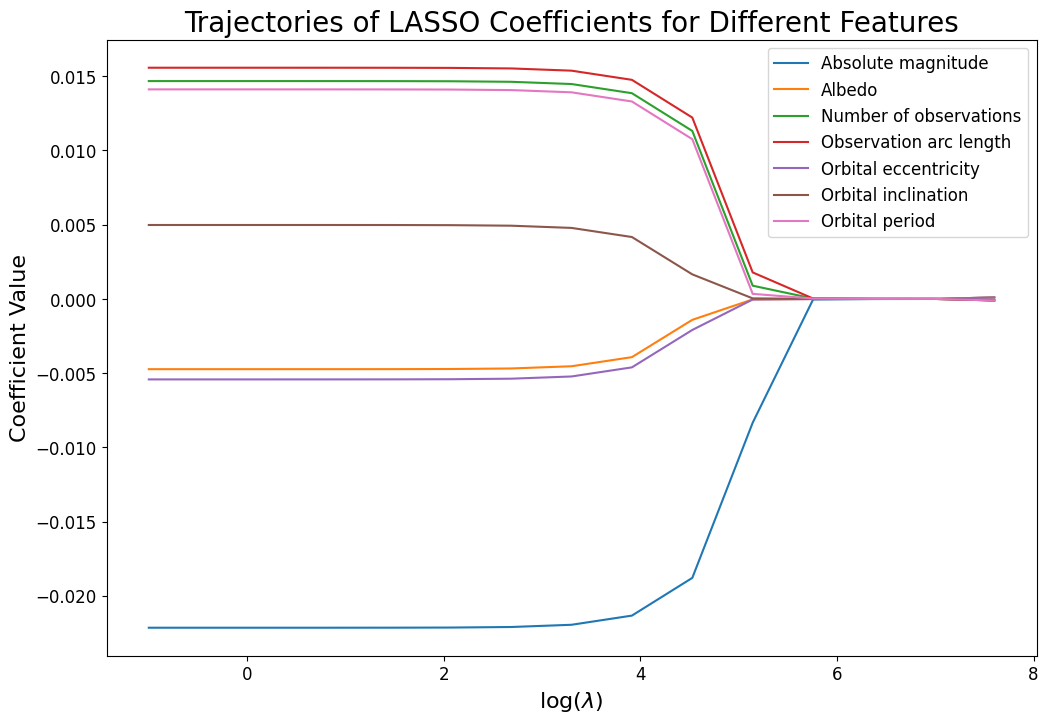

In [18]:
coeffs_lasso = lasso_coefficient_trajectories(lambdas, X_train_intercept, y_train)
print(coeffs_lasso.shape)

# plot the trajectores of LASSO coefficients using log-scale
plt.figure(figsize=(12, 8))
for i in range(coeffs_lasso.shape[1]):
    plt.plot(np.log10(lambdas), coeffs_lasso[:, i], label=features[i])

plt.xlabel(r'log($\lambda$)')
plt.ylabel('Coefficient Value')
plt.title('Trajectories of LASSO Coefficients for Different Features')
plt.legend()
plt.show()

### Comparison of LASSO (1.3) and Garrote (1.1)

Both models agrees on the selection of features to a large extent. They both select "absolute magnitude" to be the most dominant predictor. They both put importance on "number of observations" and "observation arc length". They agree that "orbital inclination" and "orbital eccentricity" are insignificant since both have a small absolute coefficient values. However, they disagree on "albedo" and "orbital period" that Garrote places higher importance on "albedo" while LASSO gives higher coefficient value to "orbital period".

There is a difference in shrinkage behavior. LASSO coefficients shrink toward 0 at $log(\lambda)<6$ earlier than those of Garrote ("absolute magnitude" turns to 0 at $log(\lambda)>6$) which maintain their magnitude for a longer range of $\lambda$ before dropping sharply. Garrote coefficients shrink more suddenly and steeply, while LASSO coefficient shrinkage is a relatively gradual process.

There is a striking difference in the range of coefficient values, highlighting the different shrinkage mechanisms. The Garrote coefficients exhibit a extremely wide range (spanning orders of magnitude from $10^{-2}$ to $10^0$ on the log scale), creating a sharp distinction between the dominant signal ("Absolute magnitude") and weaker features. In contrast, the LASSO coefficients are confined to a much narrower range (-0.025 to 0.015). This is because the LASSO's additive penalty suppresses all coefficients simultaneously.

In [19]:
def bootstrap(X, y, N_dash):
    """
    Resample without replacement B = 100 bootstrap samples of size N'from the training dataset.
    Args:
    X (np.array): The training data matrix with shape (N, p).
    y (np.array): The response column with shape (N, 1).
    N_dash (int): The size of each bootstrap sample.

    Returns:
    X_sample (np.array): The bootstrap sample of the training data matrix with shape (N', p+1).
    y_sample (np.array): The bootstrap sample of the response column with shape (N', 1).
    """
    N, p = X.shape
    training_indices = np.arange(N)
    sample = rng.choice(training_indices, N_dash, replace=False)
    X_sample = X[sample]
    y_sample = y[sample]

    # standardise the bootstrap sample
    X_sample_std = standardise(X_sample)

    # Insert 1 in every row for intercept b
    X_sample_intercept = np.hstack((np.ones((len(X_sample_std), 1)), X_sample_std))

    return X_sample_intercept, y_sample

In [20]:
def selection_probability(X, y, N_dash, lambd, B=100):
    """
    For each N' and lambda, compute the LASSO regression parameters and record which features are selected.
    Calculate the selection probability of each feature.
    Args:
    X (np.array): The training data matrix with shape (N, p).
    y (np.array): The response column with shape (N, 1).
    N_dash (int): The size of each bootstrap sample.
    lambd (float): The regularisation strength for LASSO regression.
    B (int): The number of bootstrap samples.
    """
    N, p = X.shape
    prob = np.zeros(p)
    for b in range(B):
        X_sample, y_sample = bootstrap(X, y, N_dash)
        beta_lasso = minimize_LASSO_huber(X_sample, y_sample, lambd=lambd, n_iters=10000,
                                            step_size=1e-7,
                                            c_huber=1e-4)
        selected_features = np.abs(beta_lasso[1:]) > 0.001
        prob += selected_features.flatten()
    prob = prob / B
    return prob

def selection_probability_trajectories(lambdas, X, y, N_dash, B=100):
    """Computes the trajectories of the Garrote coeffiencts for a list of lambdas.
    """
    # initialise trajectories
    sel_probs = []
    for lam in lambdas:
        # Run lasso regression and calculate the selection probabilities
        prob = selection_probability(X, y, N_dash, lam, B)
        sel_probs.append(prob)
    return np.vstack(sel_probs)

In [21]:
B = 100
N, p = X_train.shape

sel_probs_50 = selection_probability_trajectories(lambdas, X_train, y_train, 50, B)
sel_probs_319 = selection_probability_trajectories(lambdas, X_train, y_train, N//2, B)

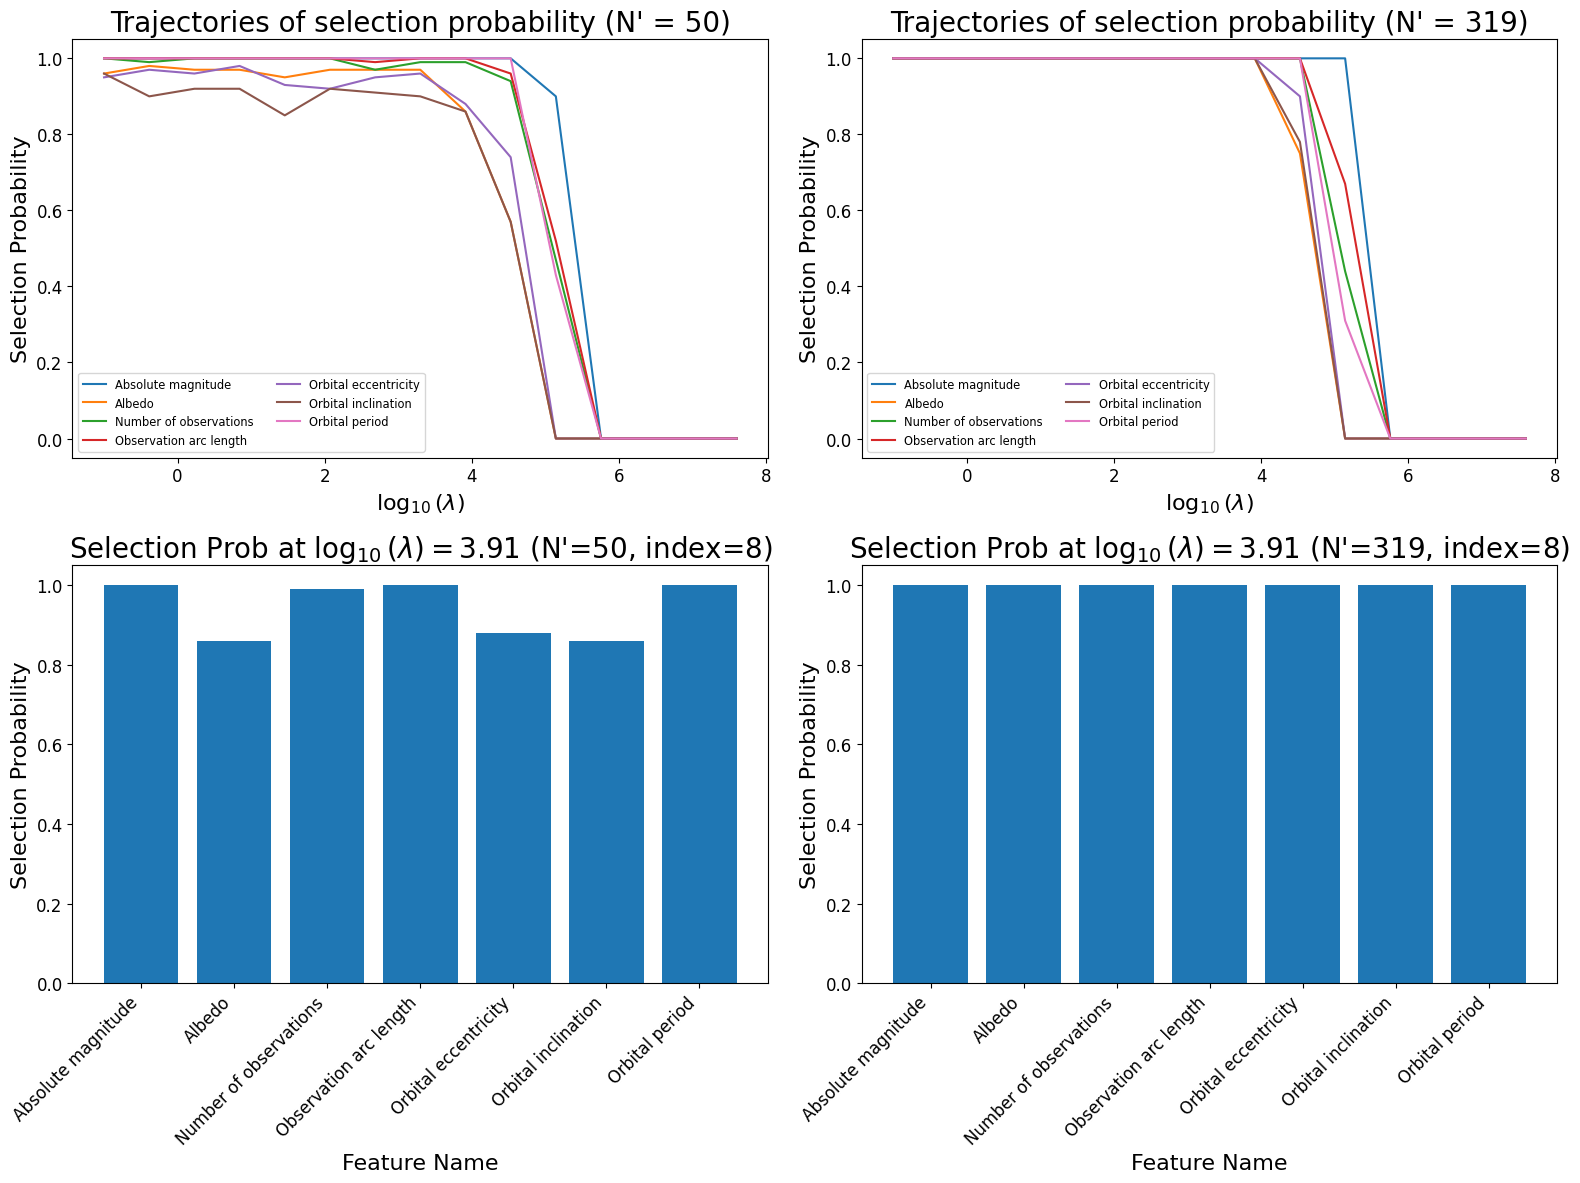

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Trajectories for N' = 50
for i in range(sel_probs_50.shape[1]):
    axes[0, 0].plot(np.log10(lambdas), sel_probs_50[:, i], label=features[i])
axes[0, 0].set_xlabel(r'$\log_{10}(\lambda)$')
axes[0, 0].set_ylabel('Selection Probability')
axes[0, 0].set_title(r"Trajectories of selection probability (N' = 50)")
axes[0, 0].legend(fontsize='x-small', ncol=2) 

# Subplot 2: Trajectories for N' = 319
for i in range(sel_probs_319.shape[1]):
    axes[0, 1].plot(np.log10(lambdas), sel_probs_319[:, i], label=features[i])
axes[0, 1].set_xlabel(r'$\log_{10}(\lambda)$')
axes[0, 1].set_ylabel('Selection Probability')
axes[0, 1].set_title(r"Trajectories of selection probability (N' = 319)")
axes[0, 1].legend(fontsize='x-small', ncol=2)

# Subplot 3: Bar chart for N' = 50
idx = 8
lam_idx = lambdas[idx]
axes[1, 0].bar(features, sel_probs_50[idx, :])
axes[1, 0].tick_params(axis='x', rotation=45)
plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha='right')
axes[1, 0].set_xlabel('Feature Name')
axes[1, 0].set_ylabel('Selection Probability')
axes[1, 0].set_title(rf"Selection Prob at $\log_{{10}}(\lambda)={np.log10(lam_idx):.2f}$ (N'=50, index={idx})")

# Subplot 4: Bar chart for N' = 319
axes[1, 1].bar(features, sel_probs_319[idx, :])
axes[1, 1].tick_params(axis='x', rotation=45)
plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha='right')
axes[1, 1].set_xlabel('Feature Name')
axes[1, 1].set_ylabel('Selection Probability')
axes[1, 1].set_title(rf"Selection Prob at $\log_{{10}}(\lambda)={np.log10(lam_idx):.2f}$ (N'={N//2}, index={idx})")

plt.tight_layout()
plt.show()


### Discussion:

The selection probability can imply the feature selection stability. A probability close to 1 or 0 indicates the high stability to be selected or not selected. If selected probability is close to 1, this feature is consistently selected across bootstrap datasets, and thus, a stable robust predictor. A probability equals to 0 implies a consistently irrevelant feature. If probabilities are around 0.5, the feature's selection is highly sensitive to small variations in the training data, so in some training samples they are selected but in other they are not selected.

Different sample size $N'$ results in different plots of selection probability. With a larger subsample ($N'=319$), the selection probabilities curves are flat and sharp, and they have fewer intermidiate probabilities, indicating a highly stable selection process. Conversely, the plot with a small sample size ($N'=50$) shows fulctuations even when $\lambda$ is small, showing the instability of the feature selection since for small sample size, the model is sensitive to outliers and noise. Thus, the stability of LASSO feature selection is heavily dependent on the sample size.

"Absolute magnitude" is the most stable feature because only it has a sharp drop in selection probability from 1 to 0 in top-right trajectory plot ($N'=319$). From the trajectory plot of $N'=50$, we can see that the blue, red, pink curves plateau at 1, showing that features "absolute magnitude", "observation arc length" and "orbital period" are stable predictors. The rest are not that stable, especially the "orbital inclination", "orbital eccentricity" and "albedo" which have the value closest to 0.5 at barchart ($N'=50$, index=8). They fluctuate most strikely in the top-left trajectory plot ($N'=50$).

<a name="task-14"></a>

## (1.4) [(index)](#index-task-14)

The metric of performance is $R^2$ score:
$$ R^2 score = 1 - \frac{SS_{res}}{SS_{tot}} $$
where $SS_{res}=\sum (y_i-\hat{y}_i)^2$ and $SS_{tot}=\sum (y_i-\bar{y})^2$.

To estimate the relative importance of each feature, we first train an ordinary linear regressor on the training data set. Then we evaluate the $R^2$ score of the regressor on the test set, calling it ${R^2}_0$. For each feature $j=1, ..., p$, we perform a randomisation over that feature by permuting the elements of the corresponding column. We re-compute the metric on this version of test set with the values at column j permuted and we denote its value in this case by ${R^2}_{j, permuted}$.

The measure of importance of feature $j$ if given by:
$$
Importance = |R^2_0 - {R^2}_{j, permuted}|
$$

In [23]:
def R2_score(y_true, y_pred):
    """
    Compute the R^2 score function.
    Args:
    y_true (np.array): Ground truth (correct) target values.
    y_pred (np.array): Estimated target values.
    Returns:
    R2 (float): The R-squared score.
    """
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    R2 = 1 - (ss_res / ss_tot)
    return R2

In [24]:
def permutation(X, column_idx):
    """Permute the values in a specific column of the feature matrix X.
    Args:    
    X (np.array): The augmented feature matrix with shape (N, p+1).
    column_idx (int): The index of the column to be permuted.
    """
    X_permuted = X.copy()
    X_permuted[:, column_idx] = rng.permutation(X_permuted[:, column_idx])
    return X_permuted

In [25]:
def variable_importance(X_test_intercept, y_true, beta_ml):
    """
    Compute the variable importance of each feature in X through the 
    difference in R^2 score before and after permutation.
    """
    N, p = X_test_intercept.shape
    y_predict = X_test_intercept @ beta_ml
    R2_0 = R2_score(y_true, y_predict)
    importance = np.zeros(p-1)
    print(f"R^2 score before permutation: {R2_0:.4f}")
    for i in range(1, p):
        X_permuted = permutation(X_test_intercept, i)
        y_permuted_predict = X_permuted @ beta_ml
        R2_permuted = R2_score(y_true, y_permuted_predict)
        importance[i-1] = abs(R2_0 - R2_permuted)
        print(f"R^2 score after permuting feature {features[i-1]}: {R2_permuted:.4f}, importance: {importance[i-1]:.4f}")
    importance = importance / np.max(importance) * 100
    return importance

R^2 score before permutation: 0.7362
R^2 score after permuting feature Absolute magnitude: -0.0977, importance: 0.8339
R^2 score after permuting feature Albedo: 0.6195, importance: 0.1167
R^2 score after permuting feature Number of observations: 0.6885, importance: 0.0477
R^2 score after permuting feature Observation arc length: 0.7189, importance: 0.0173
R^2 score after permuting feature Orbital eccentricity: 0.7361, importance: 0.0001
R^2 score after permuting feature Orbital inclination: 0.7122, importance: 0.0240
R^2 score after permuting feature Orbital period: 0.7333, importance: 0.0030


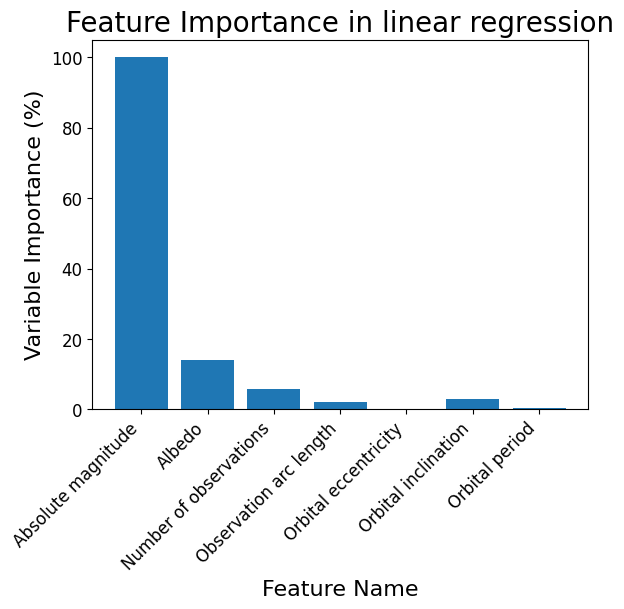

In [26]:
# Plote the bar chart of variable importance
# The coefficient of ols beta_ml is computed above in 1.1
importance = variable_importance(X_test_intercept, y_test, beta_ml)
plt.bar(features, importance)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature Name')
plt.ylabel('Variable Importance (%)')
plt.title("Feature Importance in linear regression")
plt.show()

### Discussion:

The greater the $Importance$, the more critical the feature is for the model because removing its information will cause a significant drop in $R^2$. $Importance$ near to 0 indicates that shuffling the feature has negligible impact on the model's error, suggesting the feature is redundant.

The percentage bar plot shows that "absolute magnitude" is the most dominant predictor, serving as the benchmark against which other features are scaled. The rest of the features are much less important compared to "absolute magnitude". "Albedo" and "number of observations" provide secondary and third contributions, whereas the percentage importance of "orbital eccentricity" is almost 0 and not important.

Compared with LASSO (1.3) and Garrote (1.1) coefficient plots, all of them agree that "absolute magnitude" is the most important feature as its coefficient has the largest magnitude and is the latest to become 0 in both LASSO and Garrote plot. They all agree that "orbital eccentricity" is a redundant variable. 

However, Garrote agree with this OLS feature importance that "albedo" and "number of observations" are second important features, while LASSO assigns a low value to "albedo", suggesting that it is not important. Garrote and permutation feature importance agree on insignificance of "orbital period", whereas LASSO gives higher value to it. The ranking is different. In (1.4), "albedo" is more important than "number of observations", but "number of observations"'s coefficient is higher than "albedo"'s in LASSO and Garrote.

In conclusion, Garrote is much more similar to (1.4) than LASSO is. This may be because that both Garrote and (1.4) are based on OLS, but LASSO uses a penalty to shrink all coefficients.

<a name="task-2"></a>

# Task 2: Non-linear regression with Kernel Ridge Regression [(index)](#index-task-2)

<a name="task-21"></a>

## (2.1) [(index)](#index-task-21)

**Ridge Regression** Code adapted from week 1 $\texttt{Linear regression.ipynb}$.
$$
L_{RIDGE}(\boldsymbol{\beta}) = \frac{1}{N^{train}}||\boldsymbol{y} - \boldsymbol{X} \boldsymbol{\beta}||^2 + \lambda ||\boldsymbol{\beta}||^2
$$
$\begin{align}
L_{RIDGE}(\boldsymbol{\beta}) 
&= \frac{1}{N^{train}} (\boldsymbol{y} - \boldsymbol{X} \boldsymbol{\beta})^T (\boldsymbol{y} - \boldsymbol{X} \boldsymbol{\beta}) + \lambda \boldsymbol{\beta}^T\boldsymbol{\beta} \\
&= \frac{1}{N^{train}} (\boldsymbol{y}^T\boldsymbol{y} - \boldsymbol{y}^T\boldsymbol{X} \boldsymbol{\beta} - \boldsymbol{\beta}^T \boldsymbol{X} ^T \boldsymbol{y}) + \boldsymbol{\beta}^T(\frac{1}{N^{train}} \boldsymbol{X}^T \boldsymbol{X} + \lambda \boldsymbol{I}) \boldsymbol{\beta}
\end{align}
$
Take the derivative:
$$
\nabla_{\boldsymbol{\beta}} L_\text{RIDGE}(\boldsymbol{\beta}) = - \frac{2}{N^{train}} \boldsymbol{X}^T \boldsymbol{y} + 2(\frac{1}{N^{train}}\boldsymbol{X}^T \boldsymbol{X} + \lambda I)\boldsymbol{\beta}
$$
Setting the above to 0 gives:
$$
\boldsymbol{X}^T \boldsymbol{y} = (\boldsymbol{X}^T \boldsymbol{X} + N^{train}\lambda \boldsymbol{I}) \boldsymbol{\beta}^{\star}
$$
The solution for ridge regression:
$$
\boldsymbol{\beta}^{\star}_{RIDGE} = (\boldsymbol{X}^T \boldsymbol{X} + N^{train}\lambda \boldsymbol{I})^{-1} \boldsymbol{X}^T \boldsymbol{y}
$$

In [27]:
def ridge_estimate(X, y, penalty):
    """Compute the ridge regression estimate for linear regression parameters.
    Args:
        X: N x p matrix of training inputs
        y: N x 1 vector of training targets/observations
    Returns: 
        beta_ridge: maximum likelihood parameters ((p + 1) x 1)
    """
    
    # check X and y have the same length
    assert X.shape[0] == y.shape[0], "Input X and y have different lengths."

    N, p = X.shape
    X_aug = np.hstack([np.ones((N,1)), X]) # augmented training inputs of size N x (p + 1)
    N_aug, p_aug = X_aug.shape
    I = np.identity(p_aug)
    I[0] = 0.0 # penalty excludes the bias term.
    beta_ridge = np.linalg.solve(X_aug.T @ X_aug + N * penalty * I, X_aug.T @ y)
    return beta_ridge

In [28]:
beta_ridge = ridge_estimate(X_train_std, y_train, penalty=0.1)
y_pred_train = X_train_intercept @ beta_ridge
y_pred_test = X_test_intercept @ beta_ridge

R2_train_RR = R2_score(y_train, y_pred_train)
R2_test_RR = R2_score(y_test, y_pred_test)
print(f"R^2 score of RR on training set: {R2_train_RR:.4f}")
print(f"R^2 score of RR on test set: {R2_test_RR:.4f}")

R^2 score of RR on training set: 0.7505
R^2 score of RR on test set: 0.7460


**Kernel Ridge Regression**

The loss function of kernelised version of Ridge regressor with $\beta_0=0$ could be written as:
$
\begin{align}
L(\boldsymbol{\beta}) 
&= \frac{1}{N} \sum^{N}_{i=1} (y^{(i)} - \boldsymbol{\beta}^T \phi(\boldsymbol{x}^{(i)}))^2 + \lambda ||\boldsymbol{\beta}||^2 \\
&= \frac{1}{N} ||\boldsymbol{y} - \Phi(X) \boldsymbol{\beta}||^2 + \lambda \boldsymbol{\beta}^T \boldsymbol{\beta}
\end{align}
$
where $N=N^{train}$, $\phi(\boldsymbol{x}^{(i)})$ is the non-linealy transformed vector in a higher-dimensional space (D dimension), and $\Phi(X)$ (of size $N \times D$) gives the mapping of the data matrix onto the D-dimensional transformed space such that its i-th row is $\phi(\boldsymbol{x}^{(i)})^T$. 

The optimal weight vector $\boldsymbol{\beta}$ can be expressed as a linear combination of the training samples in the feature space:
$$
\beta = \sum_{j=1}^{N} u_j \phi(x^{(j)}) = \Phi^T u
$$
where $ u = [u_1, u_2, \ldots, u_N]^T $ is the vector, and $\Phi = \Phi(X)$.

By substituting $\beta = \Phi^T u$ into the loss function, we replace explicit feature mappings with the Kernel matrix $ K = \Phi \Phi^T $:
$$\Phi \beta = \Phi \Phi^T u = Ku$$
$$ \|\beta\|^2 = (\Phi^T u)^T (\Phi^T u) = u^T \Phi \Phi^T u = u^T Ku $$

The explicit loss function for KRR becomes:

$$
L(\boldsymbol{u}) = \frac{1}{N} (y - K\boldsymbol{u})^T (y - K\boldsymbol{u}) + \lambda \boldsymbol{u}^T K\boldsymbol{u}
$$
Taking the derivative of $ L(\boldsymbol{u}) $ with respect to $ \boldsymbol{u} $ and setting it to zero:
$$
\nabla_{\boldsymbol{u}} L(\boldsymbol{u}) = \frac{2}{N} K(K\boldsymbol{u} - \boldsymbol{y}) + 2\lambda K\boldsymbol{u} = 0
$$
since $K^T = K$.

By multiplying $K^{-1}$ and dividing by 2, we have:
$$
\frac{1}{N}(K\boldsymbol{u} - \boldsymbol{y}) + \lambda \boldsymbol{u} = 0 \implies (K + N\lambda I)\boldsymbol{u} = \boldsymbol{y}
$$
The analytical solution is:
$$
\boldsymbol{u}^{\star} = (K + N\lambda I)^{-1} \boldsymbol{y}
$$

In [29]:
def kernel_matrix(X1, X2, c, n):
    """
    Calculates the kernel matrix given the data.

    Args:
        X1, X2 (np.array): Two sets of input features.
        c (float): constant.
        n (int): degree of the polynomial kernel.

    Returns:
        kernel (np.array): Kernel Matrix.
    """
    n1, m1 = X1.shape
    n2, m2 = X2.shape
    kernel = np.zeros((n1, n2))

    # Here we define a Gaussian Radial Basis Function Kernel
    kernel = (X1 @ X2.T + c) ** n
    return kernel

In [30]:
def KRR_estimate(X_train, y_train, K, penalty):
    '''Kernelized Ridge Regression estimate with polynomial kernel'''
    N, p = X_train.shape
    I = np.eye(N)
    u = np.linalg.solve(K + penalty * N * I, y_train)
    return u

In [31]:
para = [(0, 2), (1, 2), (1, 3)]
for c, n in para:
    K_train = kernel_matrix(X_train_std, X_train_std, c, n)
    u_KRR = KRR_estimate(X_train_std, y_train, K_train, penalty=0.1)
    y_pred_train = K_train @ u_KRR
    R2_train = R2_score(y_train, y_pred_train)

    K_test = kernel_matrix(X_test_std, X_train_std, c, n)
    y_pred_test = K_test @ u_KRR
    R2_test = R2_score(y_test, y_pred_test)

    print(f"R^2 score of KRR on training set with c={c}, n={n}: {R2_train:.4f}")
    print(f"R^2 score of KRR on test set with c={c}, n={n}: {R2_test:.4f}")

print(f"R^2 score of RR on training set: {R2_train_RR:.4f}")
print(f"R^2 score of RR on test set: {R2_test_RR:.4f}")

R^2 score of KRR on training set with c=0, n=2: 0.7443
R^2 score of KRR on test set with c=0, n=2: 0.6176
R^2 score of KRR on training set with c=1, n=2: 0.9533
R^2 score of KRR on test set with c=1, n=2: 0.9477
R^2 score of KRR on training set with c=1, n=3: 0.9843
R^2 score of KRR on test set with c=1, n=3: 0.9760
R^2 score of RR on training set: 0.7505
R^2 score of RR on test set: 0.7460


### Discussion:

The closer $R^2$ score to 1, the better the prediction is. From the results of $R^2$ score above, we can see that polynomial KRR with c=1, n=3 outperforms KRR with c=1, n=2 which outperforms ordinary RR which outperforms KRR with c=0, n=2.

The ordinary Ridge regressor sets a solid baseline, and it captures the linear relationship between the features and the target. $R^2 \approx 0.75$ indicates that the data has a strong linear component, but the true relationship is likely non-linear.

The KRR (n=2, c=0) performs worse than ordinary RR ($R^2 \approx 0.62 < 0.75$). This kernel ignore the linear terms and the intercept: $k(\boldsymbol{x},\boldsymbol{z}) = (\boldsymbol{x} \cdot \boldsymbol{z})^2$. The poor performance of c=0 indicates that the target variable has significant linear dependencies or a non-zero intercept that this model fails to capture.

The great improvement in $R^2$ score from kernel (n=2, c=0, $R^2 \approx 0.62$) to kernel (n=2, c=1, $R^2 \approx 0.95$) can be attributed to the introduction of constant term $c=1$. This makes the model to consider the linear terms and intercept:
$$
k(\boldsymbol{x},\boldsymbol{z}) = (\boldsymbol{x} \cdot \boldsymbol{z} + 1)^2 = 
(\boldsymbol{x}\cdot\boldsymbol{z})^2 + \underbrace{2 \boldsymbol{x} \cdot \boldsymbol{z}}_{\text{linear terms}} +
    \underbrace{1}_{\text{intercept}}
$$
Setting c=1 effectively adds lower-order terms (constant and linear) to the feature space, allowing the model to fit the data much more accurately.

Increasing the degree from n=2 to n=3 with c=1 yields a further improvement ($R^2 \approx 0.98$). This is because that the underlying relationship between the features and the target is highly non-linear, and the cubic term increases the model complexity and the ability to fit a more complex and twisted data.



<a name="task-22"></a>

## (2.2) [(index)](#index-task-22)

In [32]:
features_reduced = ['Absolute magnitude', 'Albedo']
X_train_reduced = X_train_std[:, :2]
X_test_reduced = X_test_std[:, :2]

In [33]:
# 2. Radial basis function kernel
def kernel_matrix_RBF(X1, X2, sigma=20):
    """
    Calculates the kernel matrix given the data.

    Parameters:
        X1, X2 (np.array): Two sets of input features.
        sigma (float): Hyperparameter in Gaussian kernel.

    Returns:
        kernel (np.array): Kernel Matrix.
    """
    n1, m1 = X1.shape
    n2, m2 = X2.shape
    kernel = np.zeros((n1, n2))

    # Define a Gaussian Radial Basis Function Kernel
    for i in range(n1):
        exponent = np.linalg.norm(X2 - X1[i], axis=1) ** 2
        kernel[i,:] = np.exp(-exponent / sigma)

    return kernel

3. **New kernel $k^{new}$**
$$
    k^{new}(\boldsymbol{v}, \boldsymbol{z}) = exp(\frac{-||\boldsymbol{\phi}^P(\boldsymbol{v})-\boldsymbol{\phi}^P(\boldsymbol{z})||^2}{\sigma})
$$
where
$
\begin{align}
||\boldsymbol{\phi}^P(\boldsymbol{v})-\boldsymbol{\phi}^P(\boldsymbol{z})||^2
&= (\boldsymbol{\phi}^P(\boldsymbol{v})-\boldsymbol{\phi}^P(\boldsymbol{z}))^T (\boldsymbol{\phi}^P(\boldsymbol{v})-\boldsymbol{\phi}^P(\boldsymbol{z})) \\
&= \boldsymbol{\phi}^P(\boldsymbol{v})^T \boldsymbol{\phi}^P(\boldsymbol{v}) - 2 \boldsymbol{\phi}^P(\boldsymbol{v})^T \boldsymbol{\phi}^P(\boldsymbol{z}) + \boldsymbol{\phi}^P(\boldsymbol{z})^T \boldsymbol{\phi}^P(\boldsymbol{z}) \\
&= (\boldsymbol{v} \cdot \boldsymbol{v}+1)^2 - 2 (\boldsymbol{v} \cdot \boldsymbol{z}+1)^2 + (\boldsymbol{z} \cdot \boldsymbol{z}+1)^2
\end{align}
$
Thus, we can substitute equation (11) back to the $k^{new}$.

In [34]:
# 3. new kernel
def kernel_matrix_new(X1, X2, sigma=20, c=1, n=2):
    """
    Calculates the kernel matrix given the data.

    Args:
        X1, X2 (np.array): Two sets of input features.
        sigma (float): Hyperparameter in Gaussian kernel.

    Returns:
        kernel (np.array): Kernel Matrix.
    """
    n1, m1 = X1.shape
    n2, m2 = X2.shape
    kernel = np.zeros((n1, n2))

    # define a new Kernel composing Gaussian Radial Basis Function and polynomial kernel
    X2_diag = np.dot(X2, X2.T).diagonal()
    for i in range(n1):
        exponent = (np.dot(X1[i], X1[i])+c)**n + (X2_diag+c)**n - 2 * (X2 @ X1[i]+c)**n
        kernel[i,:] = np.exp(-exponent / sigma)

    return kernel

In [70]:
def plot_3d(ax, X_train_reduced, y_train, title, penalty):

    x1 = X_train_reduced[:, 0]
    x2 = X_train_reduced[:, 1]

    x1_min, x1_max = x1.min(), x1.max()
    x2_min, x2_max = x2.min(), x2.max()

    grid = 30
    x1_grid, x2_grid = np.meshgrid(
        np.linspace(x1_min, x1_max, grid),
        np.linspace(x2_min, x2_max, grid)
    )

    grid_points = np.column_stack([x1_grid.ravel(), x2_grid.ravel()])

    # Compute the kernel matrices of training set and grid points for each kernel type
    if title == 'Polynomial Kernel':
        K_grid = kernel_matrix(grid_points, X_train_reduced, c=1, n=2)
        K = kernel_matrix(X_train_reduced, X_train_reduced, c=1, n=2)
    elif title == 'RBF Kernel':
        K_grid = kernel_matrix_RBF(grid_points, X_train_reduced, sigma=20)
        K = kernel_matrix_RBF(X_train_reduced, X_train_reduced, sigma=20)
    elif title == 'New Kernel':
        K_grid = kernel_matrix_new(grid_points, X_train_reduced, sigma=20, c=1, n=2)
        K = kernel_matrix_new(X_train_reduced, X_train_reduced, sigma=20, c=1, n=2)

    # Compute the KRR estimate
    u = KRR_estimate(X_train_reduced, y_train, K, penalty)

    #Calculate and print R^2 score on training set
    y_pred = K @ u
    R2 = R2_score(y_train, y_pred)
    print(f"R^2 score of KRR with {title} on training set with penalty of {p}: {R2:.4f}")
    
    # plot predicted surface
    y_grid_pred = (K_grid @ u).reshape(x1_grid.shape)

    ax.plot_surface(
        x1_grid, x2_grid, y_grid_pred,
        cmap=cm.viridis, alpha=0.5
    )

    # scatter the training points
    ax.scatter(x1, x2, y_train.flatten(),
               c='red', s=15)

    ax.set_title(rf'{title} $\lambda={penalty}$', fontsize=10)
    ax.set_xlabel('Absolute Magnitude')
    ax.set_ylabel('Albedo')
    ax.set_zlabel('Diameter')


R^2 score of KRR with Polynomial Kernel on training set with penalty of 0.1: 0.9504
R^2 score of KRR with RBF Kernel on training set with penalty of 0.1: 0.4220
R^2 score of KRR with New Kernel on training set with penalty of 0.1: 0.3961
R^2 score of KRR with Polynomial Kernel on training set with penalty of 300: -0.7456
R^2 score of KRR with RBF Kernel on training set with penalty of 300: -0.7804
R^2 score of KRR with New Kernel on training set with penalty of 300: -0.7820


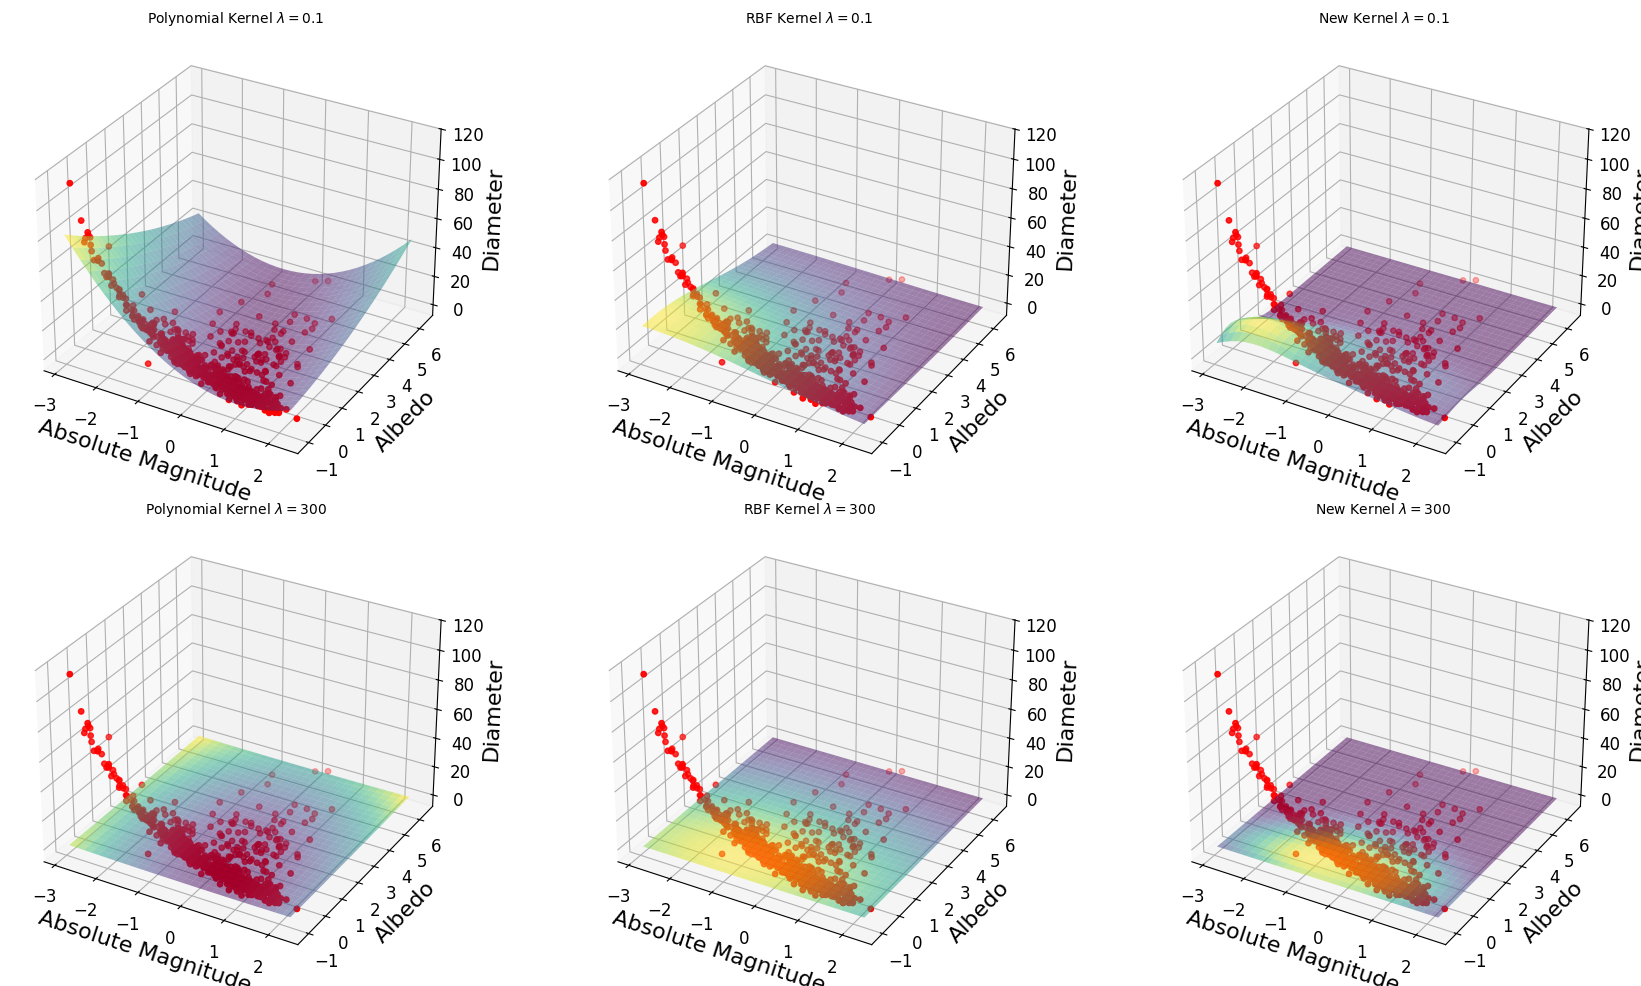

In [71]:
penalty = [0.1, 300]
names = ['Polynomial Kernel', 'RBF Kernel', 'New Kernel']

fig = plt.figure(figsize=(18, 10))

# Plot a 2*3 grid of 3D surface plots for the three kernels and two penalty values
count = 1
for p in penalty:
    for name in names:

        ax = fig.add_subplot(2, 3, count, projection='3d')

        plot_3d(
            ax,
            X_train_reduced,
            y_train,
            title=name,
            penalty=p
        )

        count += 1

plt.tight_layout()
plt.show()

### Discussion:

The polynomial kernel achieves an excellent fit with a training $R^2$ of 0.9504 when $\lambda = 0.1$. The 3D plot shows that the polynomial kernel creates a curved surface that rises sharply for low values of "absolute magnitude", perfectly matching the distribution of the red data points. The physical relationship between "asteroid diameter" and "absolute magnitude" is roughly exponential, which can be fitted by polynomial effectively. This shows that the polynomial kernel is unbounded and can model the rapid growth.

Both RBF and new kernels perform poorly, with $R^2$ scores of 0.4220 and 0.3961 respectively. The 3D plots for these kernels are relatively flat compared to the steep rise in the data. They have a "bump" at the edges of the feature space but fail to capture the steeply high "diameter" values. The value of RBF kernel depends on the distance between points scaled by $\sigma$. $\sigma=20$ is very large compared to the standardized data range (which is roughly -3 to 3 and -1 to 7). A large $\sigma$ makes the RBF kernel overly smooth and flat, preventing it from modeling sharp, local variations. The "new kernel" is derived from the RBF structure, suffering from the same limitation.

The parameter $\lambda$ controls the regularization strength. Increasing $\lambda$ imposes a heavy penalty on the magnitude of the coefficients, forcing the model to become simpler and flat. When $\lambda$ is increased to 300, the $R^2$ scores for all three kernels drop significantly to negative values (-0.75 to -0.78), worse than prediction of mean of the target variable. This shows that the model is highly sensitive to $\lambda$ and high $\lambda$ make the model lose the flexibility to follow the data's curvature.

<a name="task-3"></a>

# Task 3: Classification with the Multi-Layer Perceptron [(index)](#index-task-3)

<a name="task-31"></a>

## (3.1) [(index)](#index-task-31)

**Data Processing**


In [37]:
diag_map = {'MBA': 0, 'OMB': 1, 'TJN':2}
df_train['class id'] = df_train['Asteroid class'].map(diag_map)
df_test['class id'] = df_test['Asteroid class'].map(diag_map)

y2_train = df_train['class id'].values
y2_test = df_test['class id'].values
df_train.head()


,Absolute magnitude,Albedo,Number of observations,Observation arc length,Orbital eccentricity,Orbital inclination,Orbital period,Asteroid diameter,Asteroid class,class id
0,18.1,0.041,15,2.0,0.201590,11.975800,3.912298,1.573,MBA,0
1,12.5,0.139,349,7208.0,0.032746,8.793883,11.942668,12.355,TJN,2
2,14.1,0.062,705,25309.0,0.179314,27.433960,5.749452,8.862,OMB,1
3,16.9,0.097,91,3805.0,0.066114,13.813845,4.592982,2.139,MBA,0
4,11.5,0.062,1300,9606.0,0.008824,5.595907,12.006096,30.763,TJN,2


In [38]:
def dense(X, W, b):
    """Full-connected MLP layer.

    Args:
        X (np.ndarray): K x h_in array of inputs, where K is the batch size and h_in is the input dimension.
        W (np.ndarray): h_out x h_in array for weights matrix parameters, where h_out is the output dimension.
        b (np.ndarray): Length h_out 1-D array for bias parameters

    Returns:
        a (np.ndarray): K x h_out array of pre-activations
    """
    a = np.vstack([W @ x + b for x in X])
    return a

In [39]:
def relu_activation(a):
    """ReLU activation function.

    Args:
        a: K x h_out array of pre-activations

    Returns:
        h: K x h_out array of post-activations
    """
    # compute post-activations
    h = np.maximum(a, 0.)
    return h


def grad_relu_activation(a):
    """Gradient of ReLU activation function.

    Args:
        a: K x h_out array of pre-activations

    Returns:
        grad: K x h_out gradient array of post-activations
    """
    # compute gradient
    grad = np.zeros_like(a)
    grad[a>0] = 1
    return grad

In [40]:
# A lookup table for activation functions by their names.
activation_table = {
    "relu": relu_activation,
    # Identity function.
    "identity": lambda x: x
}

# A lookup table for gradient of activation functions by their names.
grad_activation_table = {
    "relu": grad_relu_activation,
    # Identity function gradient.
    "identity": lambda x: np.ones_like(x)
}

In [41]:
class MLP:
    """
    This class represents a Multi-Layer Perceptron (MLP), that we are going
    to use to encapsulate two components:
        1. layers: the sequence of layers, where each layer is stored in
            a dictionary in the format {"W": np.ndarray, "b": np.ndarray},
            where "W" points to the weights array, and "b" points to
            the bias vector.
        2. rng: a pseudo random number generator (RNG) initialised to generate
            the random weights in a reproducible manner between different
            runtime sessions.
    This class is also shipped with methods that perform essential operations
    with a MLP, including:
        - add_layers: which creates a new layer with specified dimensions.
        - predict: applies the MLP forward pass to make predictions and produces
            a computational graph for the forward pass that can be used to
            compute gradients using backpropagation algorithm.
        in addition to other light functions that return simple statistics about
        the MLP.
    """
    def __init__(self, seed=42):
        self.layers = []
        self.rng = np.random.default_rng(seed)

    def n_parameters(self):
        """Return the total number of parameters of weights and biases."""
        return sum(l["b"].size + l["W"].size for l in self.layers)

    def n_layers(self):
        """Return current number of MLP layers (including input and output)."""
        return len(self.layers) + 1 if len(self.layers) > 0 else 0

    def layer_dim(self, index):
        """Retrieve the dimensions of the MLP layer at `index`."""
        return self.layers[index]["W"].shape

    def add_layer(self, in_dim, out_dim, activation="identity"):
        """Add fully connected layer to MLP.

        Parameters:
            in_dim (int): The input dimension of the layer.
            out_dim (int): The output dimension of the layer.
            activation (str): The activation function name.
        """
        # check if input-dimension matches output-dimension of previous layer
        if self.n_layers() > 0:
            last_out_dim, _ = self.layer_dim(-1)
            assert in_dim == last_out_dim, f"Input-dimension {in_dim} does not match output-dimension {last_out_dim} of previous layer."

        # the first layer, in our convention illustrated, does not apply activation on the input features X.
        if self.n_layers() == 0:
            assert activation == "identity", "Should not apply activations on the input features X, use Identity function for the first layer."


        # store each layer as a dictionary in the list, as shown in the
        # attached diagram.
        self.layers.append({
            # only for debugging.
            "index": len(self.layers),
            # apply Glorot initialisation for weights.
            # hint: use self.rng.normal()
            "W": self.rng.normal(size=(out_dim, in_dim)) * np.sqrt(2. / (in_dim + out_dim)),
            # initialise bias vector with zeros.
            "b": np.zeros(out_dim),
            # store the activation function (as string)
            "activation": activation
        })

    def predict(self, X):
        """Apply the forward pass on the input X and produce prediction and the
        forward computation graph.

        Parameters:
            X (np.ndarray): Feature matrix.

        Returns:
            (np.ndarray, List[Dict[str, np.ndarray]]): A tuple of the
            predictions and the computation graph as a sequence of intermediate
            values through the MLP, specifically each layer will have a corresponding
            intermediate values {"a": np.ndarray, "h": np.ndarray}, as shown in the
            attached diagram above.
        """
        # We assume that we work with a batch of examples (ndim==2).
        if X.ndim == 1:
            # If one example passed, add a dummy dimension for the batch.
            X = X.reshape(1, -1)

        # store pre- and post-activations in list
        forward_pass = [{"index": 0, "a": X, "h": X}]

        # iterate through hidden layers
        for k in range(1, len(self.layers)):
            # compute pre-activations
            a = dense(forward_pass[k - 1]["h"], self.layers[k - 1]["W"], self.layers[k - 1]["b"])
            activation = activation_table[self.layers[k]["activation"]]
            forward_pass.append({"index": k, "a" : a, "h" : activation(a)})

        y_hat = dense(forward_pass[-1]["h"], self.layers[-1]["W"], self.layers[-1]["b"])
        # predicted target is output of last layer
        return y_hat, forward_pass

In [42]:
def softmax(z):
    """
    Compute softmax values for each set of scores in z.
    Args:
        z: np.array with shape (N, C) where N is batch size, C is number of classes.
    Returns:
        (N, C) np.array of softmax probabilities.
    """
    e_z = np.exp(z)
    return e_z / np.sum(e_z, axis=1, keepdims=True)

def one_hot(y, n_classes):
    """
    Converts a vector of class integers to a one-hot matrix.
    Args:
        y: (N,) np.array of class labels
        n_classes: int, number of classes
    Returns:
        one_hot_mat: (N, n_classes) np.array of one-hot encoded labels.
    """
    y = y.astype(int)
    n_samples = y.shape[0]
    one_hot_mat = np.zeros((n_samples, n_classes))
    one_hot_mat[np.arange(n_samples), y.ravel()] = 1
    return one_hot_mat

**Cross-entropy**
$$
CE = - \sum^{N^{train}}_{i=1} \sum^{Q-1}_{q=0} y^{(i)}_q log p^{(i)}_q
$$

**Cross-Entropy Gradient**

Let $z^{(i)}$ be the logits (input to Softmax) and $y^{(i)}$ be the one-hot encoded ground truth vector for sample $i$.

* **Softmax Function:** $p^{(i)}_k = \frac{e^{z^{(i)}_k}}{\sum_{j} e^{z^{(i)}_j}}$

* **Cross-Entropy Loss:** $L^{(i)} = - \sum_{k} y^{(i)}_k \log(p^{(i)}_k)$

We want to find the gradient of the loss with respect to the logit $z^{(i)}_j$:
$$\frac{\partial L^{(i)}}{\partial z^{(i)}_j}$$

Since $z^{(i)}_j$ affects the loss through all probabilities $p^{(i)}_k$, we sum over all classes $k$:
$$\frac{\partial L^{(i)}}{\partial z^{(i)}_j} = \sum_{k} \frac{\partial L^{(i)}}{\partial p^{(i)}_k} \cdot \frac{\partial p^{(i)}_k}{\partial z^{(i)}_j}$$

First, the derivative of Loss w.r.t probability $p^{(i)}_k$:
$$\frac{\partial L^{(i)}}{\partial p^{(i)}_k} = - \frac{y^{(i)}_k}{p^{(i)}_k}$$

Second, the derivative of Softmax $p^{(i)}_k$ w.r.t logit $z^{(i)}_j$. There are two cases:
* **Case 1 ($k=j$):**
    $$\frac{\partial p^{(i)}_j}{\partial z^{(i)}_j} = p^{(i)}_j(1 - p^{(i)}_j)$$
* **Case 2 ($k \neq j$):**
    $$\frac{\partial p^{(i)}_k}{\partial z^{(i)}_j} = -p^{(i)}_k p^{(i)}_j$$

Substitute these back into the Chain Rule equation, splitting the sum into $k=j$ and $k \neq j$:

$$
\begin{align}
\frac{\partial L^{(i)}}{\partial z^{(i)}_j} &= \underbrace{\left( -\frac{y^{(i)}_j}{p^{(i)}_j} \right) p^{(i)}_j(1-p^{(i)}_j)}_{k=j} + \sum_{k \neq j} \underbrace{\left( -\frac{y^{(i)}_k}{p^{(i)}_k} \right) (-p^{(i)}_k p^{(i)}_j)}_{k \neq j} \\
&= -y^{(i)}_j(1 - p^{(i)}_j) + \sum_{k \neq j} y^{(i)}_k p^{(i)}_j \\
&= -y^{(i)}_j + y^{(i)}_j p^{(i)}_j + p^{(i)}_j \sum_{k \neq j} y^{(i)}_k \\
&= -y^{(i)}_j + p^{(i)}_j \left( y^{(i)}_j + \sum_{k \neq j} y^{(i)}_k \right)
\end{align}
$$

Since $y^{(i)}$ is a one-hot vector, the sum of all elements is 1 ($\sum_{all \, k} y^{(i)}_k = 1$). Therefore:

$$
\frac{\partial L^{(i)}}{\partial z^{(i)}_j} = -y^{(i)}_j + p^{(i)}_j(1) = p^{(i)}_j - y^{(i)}_j
$$


In [43]:
def cross_entropy_loss(y_true_labels, y_logits):
    """
    Compute Cross-Entropy Loss.
    Args:
        y_true_labels (np.array): class integers (0, 1, 2) with shape (N,)
        y_logits (np.array): raw output scores from the MLP with shape (N, C)

    Returns:
        loss (float): The cross-entropy loss value.
    """
  
    probs = softmax(y_logits)
    y_one_hot = one_hot(y_true_labels, n_classes=y_logits.shape[1])
    loss = -np.sum(y_one_hot * np.log(probs + 1e-9))
    return loss

def grad_cross_entropy_loss(y_true_labels, y_logits):
    """
    Compute Gradient of Cross-Entropy Loss with respect to the logits.
    Args:
        y_true_labels (np.array): class integers (0, 1, 2) with shape (N,)
        y_logits (np.array): raw output scores from the MLP with shape (N, C)

    Returns:
        grad (np.array): Gradient of the loss with respect to the logits, with shape (N, C)
    """
    probs = softmax(y_logits)
    y_one_hot = one_hot(y_true_labels, n_classes=y_logits.shape[1])
    grad = (probs - y_one_hot)
    return grad


In [74]:
def mse_loss(y_true, y_pred):
    """Compute MSE-loss

    Parameters:
        y_true: ground-truth array, with shape (K, C)
        y_pred: predictions array, with shape (K, C)

    Returns:
        loss (float): MSE-loss
    """
    assert y_true.size == y_pred.size, "Ground-truth and predictions have different dimensions."

    # Adjustment to avoid subtraction between (K,) and (1, K) arrays.
    y_true = y_true.reshape(y_pred.shape)

    # Compute MSE loss
    loss = np.mean((y_true - y_pred)**2)
    return loss

def grad_mse_loss(y_true, y_pred):
    """Compute gradient of MSE-loss

    Parameters:
        y_true: ground-truth values, shape: (K, C).
        y_pred: prediction values, shape: (K, C).

    Returns:
        grad (np.ndarray): Gradient of MSE-loss, shape: (K, ).
    """
    # Adjustment to avoid subtraction between (K,) and (1, K) arrays.
    y_true = y_true.reshape(y_pred.shape)

    # Compute gradient of MSE loss
    grad = 2 * (y_pred - y_true) / y_true.size
    return grad

In [45]:
def backpropagate(layers, forward_pass, delta_output):
    """
    Apply the backpropagation algorithm to the MLP layers to compute the gradients starting from
    the output layer to the input layer, and starting the chain rule from the
    partial derivative of the loss function w.r.t the predictions y_hat$

    Parameters:
        layers (List[Dict[str, np.ndarray]]): The MLP sequence of layers, as shown in the diagrams.
        forward_pass (List[Dict[str, np.ndarray]]): The forward pass intermediate values for
            each layer, representing a computation graph.
        delta_output (np.ndarray): the partial derivative of the loss function w.r.t the
            predictions y_hat, has the shape (K, 1), where K is the batch size.
    Returns:
        gradients (List[Dict[str, np.ndarray]]): The computed gradient using a structure symmetric in the layers, as shown
            in the diagrams.

    """
    # Create a list that will contain the gradients of all the layers.
    gradients = []

    # Initialise delta.
    delta = delta_output

    assert len(layers) == len(forward_pass), "Number of layers is expected to match the number of forward pass layers"

    # Iterate on layers backwardly, from output to input.
    # Calculate gradients w.r.t. weights and biases of each level and store in list of dictionaries.
    for layer, forward_computes in reversed(list(zip(layers, forward_pass))):   # zip iterates through pairs of layers and forward_pass
        assert forward_computes["index"] == layer["index"], "Mismatch in the index."

        h = forward_computes["h"]
        assert delta.shape[0] == h.shape[0], "Mismatch in the batch dimension."

        # Gradients are average gradients over batch
        gradients.append({"W" : (delta.T @ h) / h.shape[0],
                          "b" : delta.mean(axis=0)})

        # Update the delta for the next iteration
        grad_activation_f = grad_activation_table[layer["activation"]]
        grad_activation = grad_activation_f(forward_computes["a"])

        # Calculate the delta for the backward layer.
        delta = grad_activation * (delta @ layer["W"])


    # Return now ordered list matching the layers.
    gradients = list(reversed(gradients))
    return gradients

In [46]:
def sgd_step(X, y, mlp, learning_rate = 1e-3, mode="CE"):
    """
    Apply a stochastic gradient descent step using the sampled batch.
    Parameters:
        X (np.ndarray): The input features array batch, with dimension (K, p).
        y (np.ndarray): The ground-truth of the batch, with dimension (K, 1).
        learning_rate (float): The learning rate multiplier for the update steps in SGD.
    Returns:
        updated_layers (List[Dict[str, np.ndarray]]): The updated layers after applying SGD.
    """
    # Compute the forward pass.
    y_hat, forward_pass = mlp.predict(X)

    # Compute the partial derivative of the loss w.r.t. to predictions `y_hat`.
    if mode == "mse":
        delta_output = grad_mse_loss(y, y_hat)
    elif mode == "CE":
        delta_output = grad_cross_entropy_loss(y, y_hat)

    # Apply backpropagation algorithm to compute the gradients of the MLP parameters.
    gradients = backpropagate(mlp.layers, forward_pass, delta_output)

    # mlp.layers and gradients are symmetric, as shown in the figure.
    updated_layers = []
    for layer, grad in zip(mlp.layers, gradients):
        W = layer["W"] - learning_rate * grad["W"]
        b = layer["b"] - learning_rate * grad["b"]
        updated_layers.append({"W": W, "b": b,
                               # keep the activation function.
                               "activation": layer["activation"],
                               # We use the index for asserts and debugging purposes only.
                               "index": layer["index"]})
    return updated_layers

In [47]:
def accuracy(y_true, y_logits):
    """Accuracy for classification"""
    predictions = np.argmax(y_logits, axis=1)
    return np.mean(predictions == y_true.ravel())

In [73]:
def sgd(X_train, y_train, X_test, y_test, mlp, learning_rate = 0.04,
        n_epochs=10, minibatchsize=1, mode="CE", seed=42):
    """
    Run the Stochastic Gradient Descent (SGD) algorithm to optimise the parameters of MLP model to fit it on
    the training data using MSE loss.

    Args:
        X_train (np.ndarray): The training data features, with shape (N^{training}, p).
        y_train (np.ndarray): The training data ground-truth, with shape (N^{training}, 1).
        X_test (np.ndarray): The testing data features, with shape (N^{test}, p).
        y_test (np.ndarray): The testing data ground-truth, with shape (N^{test}, 1).
        mlp (MLP): The MLP object enacpsulating the MLP model.
        learning_rate (float): The learning_rate multiplier used in updating the parameters at each iteration.
        n_epochs (int): The number of training cycles that each covers the entire training examples.
        minibatchsize (int): The batch size used in each SGD step.
        seed (int): A seed for the RNG to ensure reproducibility across runtime sessions.

    Returns:
        mlp (MLP): MLP object encapuslating the trained MLP model.
        losses_train (np.ndarray): Train losses over epochs.
        losses_tset (np.ndarray): Test losses over epochs.
    """

    # get random number generator
    rng = np.random.default_rng(seed)

    # compute number of iterations per epoch
    n_iterations = int(len(y_train) / minibatchsize)

    # store losses
    losses_train = []
    losses_test = []

    for i in range(n_epochs):

        # shuffle data
        p = rng.permutation(len(y_train))
        X_train_shuffled = X_train[p]
        y_train_shuffled = y_train[p]

        for j in range(n_iterations):
            # get batch
            X_batch = X_train_shuffled[j * minibatchsize : (j+1) * minibatchsize]
            y_batch = y_train_shuffled[j * minibatchsize : (j+1) * minibatchsize]

            # apply sgd step
            updated_layers = sgd_step(X_batch, y_batch, mlp, learning_rate, mode=mode)

            # update weights and biases of MLP
            mlp.layers = updated_layers

        # compute loss at the end of each epoch
        y_hat_train, _ = mlp.predict(X_train)
        y_hat_test, _ = mlp.predict(X_test)
        
        if mode == "CE":
            loss_train = cross_entropy_loss(y_train, y_hat_train).squeeze()
            loss_test = cross_entropy_loss(y_test, y_hat_test).squeeze()
        
        elif mode == "mse":
            loss_train = mse_loss(y_train, y_hat_train)
            loss_test = mse_loss(y_test, y_hat_test)

        losses_train.append(loss_train)
        losses_test.append(loss_test)

        if (i==0) or ((i+1)%(n_epochs//10)==0):
            if mode == "CE":
                print(
                    f'Epoch {i+1}/{n_epochs}: In-sample loss: {loss_train}, Out-of-sample loss: {loss_test},'
                    f'train accuracy: {accuracy(y_train, y_hat_train):.4f}, test accuracy: {accuracy(y_test, y_hat_test):.4f}.'
                    )


    return mlp, losses_train, losses_test

In [49]:
# compile architecture of MLP
mlp = MLP(seed=2)
mlp.add_layer(X_train.shape[1], 64)    
mlp.add_layer(64, 64, "relu")            
mlp.add_layer(64, 32, "relu")          
mlp.add_layer(32, 3, "relu")            
print("Number of layers (including input and output layer):",mlp.n_layers())
print("Number of trainable parameters:",mlp.n_parameters())

# train MLP using SGD
mlp, losses_train, losses_test = sgd(X_train_std, y2_train, X_test_std, y2_test,
                                     mlp, learning_rate = 0.04,
                                     n_epochs=500,
                                     minibatchsize=64)

Number of layers (including input and output layer): 5
Number of trainable parameters: 6851
Epoch 1/500: In-sample loss: 630.2823114842624, Out-of-sample loss: 157.31491873143003,train accuracy: 0.4279, test accuracy: 0.4437.
Epoch 50/500: In-sample loss: 92.48927360149659, Out-of-sample loss: 32.13381860251325,train accuracy: 0.9451, test accuracy: 0.9437.
Epoch 100/500: In-sample loss: 47.81238805353102, Out-of-sample loss: 21.654584631222647,train accuracy: 0.9781, test accuracy: 0.9437.
Epoch 150/500: In-sample loss: 30.589208746760065, Out-of-sample loss: 19.385556088866892,train accuracy: 0.9843, test accuracy: 0.9437.
Epoch 200/500: In-sample loss: 20.4239147783051, Out-of-sample loss: 15.956792916786664,train accuracy: 0.9875, test accuracy: 0.9437.
Epoch 250/500: In-sample loss: 14.2035202230649, Out-of-sample loss: 14.892465232384197,train accuracy: 0.9969, test accuracy: 0.9688.
Epoch 300/500: In-sample loss: 12.900512590917348, Out-of-sample loss: 15.866016527127153,train a

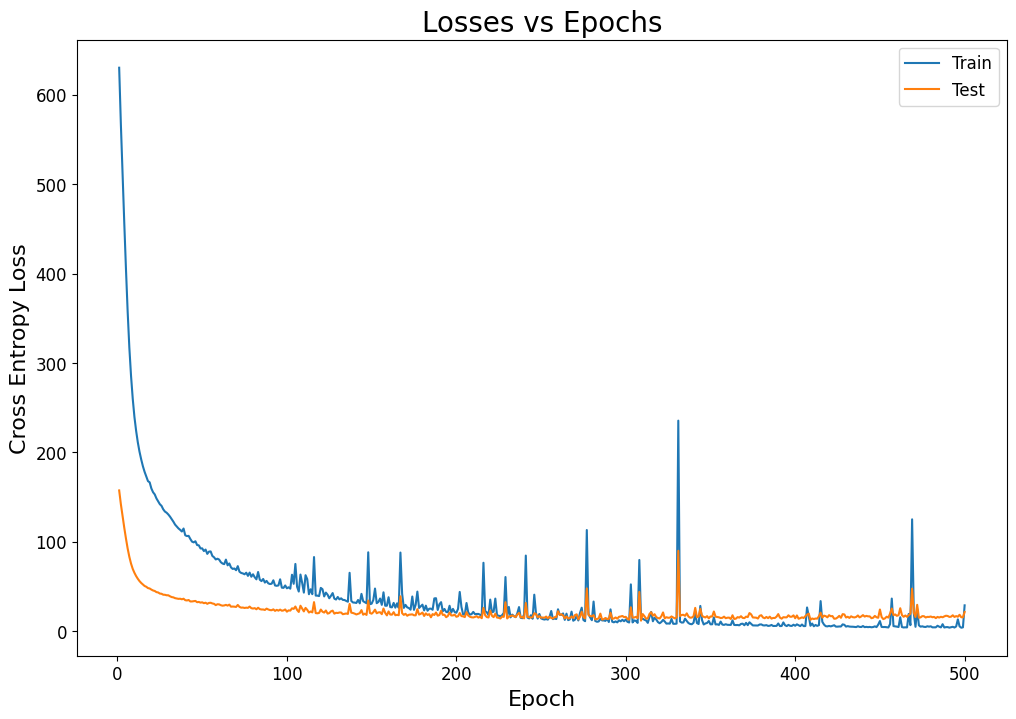

In [50]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(np.arange(1,501),losses_train, label="Train")
ax.plot(np.arange(1,501),losses_test, label="Test")
ax.set(title="Losses vs Epochs", xlabel = "Epoch", ylabel = "Cross Entropy Loss")
ax.legend()
plt.show()

### Comment:

This plot demonstrates that the MLP converges successfully. Both training (blue) and test (orange) losses drop sharply within the first 50 epochs, indicating that the chosen learning rate (0.04) and architecture were sufficient for the model to quickly learn the coarse features of the data. After approximately 150 epochs, the test loss plateaus and remains relatively stable (not an upward trend), while the training loss continues to decrease slowly towards zero, showing that while there is some overfitting, it is not severe overfitting where the test error explodes. The model generalizes well. 

There are noticeable spikes in the loss curve. Since the gradient is estimated on a small subset of data (batch size = 64) rather than the whole dataset, and the Cross-Entropy loss is summation instead of taking the mean,"noisy" batches or a relatively high gradient of loss can cause the optimization to temporarily jump to a higher loss region before settling back down.

In [51]:
logits, _ = mlp.predict(X_test_std)

def per_class_accuracy(logits, y_true):
    """Calculate per-class accuracy."""

    y_preds = np.argmax(logits, axis=1)
    class_names = {0: 'MBA', 1: 'OMB', 2: 'TJN'}
    acc_qs = []

    for q in [0, 1, 2]:
        idx_class_q = (y_true == q)
        total_q = np.sum(idx_class_q)
        correct_q = np.sum(y_preds[idx_class_q] == q)
        acc_q = correct_q / total_q
        acc_qs.append(acc_q)
        print(f"Class {q} ({class_names[q]}): {acc_q:.4f} ({correct_q}/{total_q})")


In [52]:
per_class_accuracy(logits, y2_test)

Class 0 (MBA): 0.9623 (51/53)
Class 1 (OMB): 0.8596 (49/57)
Class 2 (TJN): 1.0000 (50/50)


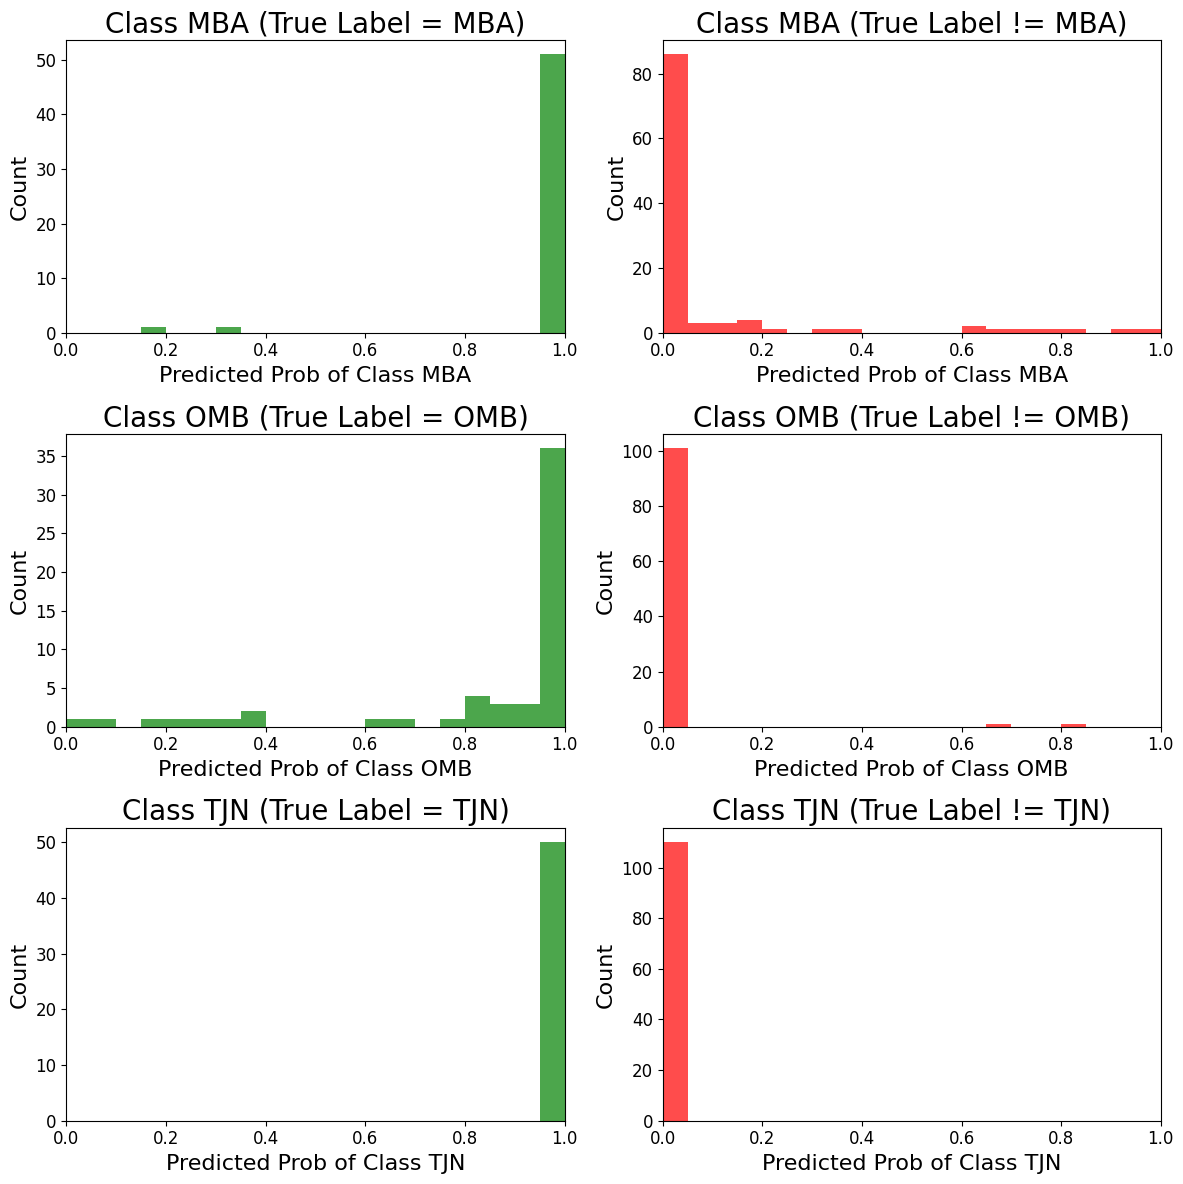

In [53]:
# 6 Count histograms

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
classes = [0, 1, 2]
class_labels = ['MBA', 'OMB', 'TJN']

logits, _ = mlp.predict(X_test_std)
probs = softmax(logits)

for q in classes:
    # true label is q
    probs_in_class = probs[y2_test == q, q]
    
    # true label is not q
    probs_out_class = probs[y2_test != q, q]
    
    # In-class Histograms
    ax1 = axes[q, 0]
    ax1.hist(probs_in_class, bins=20, range=(0, 1), color='green', alpha=0.7)
    ax1.set_title(f'Class {class_labels[q]} (True Label = {class_labels[q]})')
    ax1.set_xlabel(f'Predicted Prob of Class {class_labels[q]}')
    ax1.set_ylabel('Count')
    ax1.set_xlim(0, 1)
    
    # Out-of-class Histograms
    ax2 = axes[q, 1]
    ax2.hist(probs_out_class, bins=20, range=(0, 1), color='red', alpha=0.7)
    ax2.set_title(f'Class {class_labels[q]} (True Label != {class_labels[q]})')
    ax2.set_xlabel(f'Predicted Prob of Class {class_labels[q]}')
    ax2.set_ylabel('Count')
    ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()


### Discussion:
The MLP classifier has learned a perfect decision boundary for the TJN class as per-class accuracy $ACC_{TJN}$ reaches 100%. The histograms show that every sample that belongs to TJN has a predicted probability near 1.0, and every sample that does not belong to TJN has a predicted probability near 0.0. This shows that the classifier would not misclasify TJN and orther two classes, indicating that in the feature space, TJN are likely distinct and well-separated from MBA and OMB.

The model is highly effective at identifying MBA asteroids, with very little ambiguity ($ACC_{MBA}\approx 0.9623$). The histograms (top-left) show that the vast majority of true MBA samples are clustered at probability 1.0 with a very small number of misclassifications to OMB (shown by middle-right plot).

OMB is the hardest class to classify as its per-class accuracy is approximately 85.96%. The histograms show that while there is a peak at 1.0, there are several samples with predicted probabilities scattered between 0.0 and 0.8. This indicates ambiguity. The model is often unsure about OMB asteroids, assigning them low probability or confusing them with MBA. This suggests that the features of OMB overlap significantly with those of MBA, making it difficult for the MLP to draw a clean separating hyperplane between them.

<a name="task-32"></a>

## (3.2) [(index)](#index-task-32)

In [54]:
def weak_model(X, seed=2):
    mlp = MLP(seed=seed)
    mlp.add_layer(X.shape[1], 32)    
    mlp.add_layer(32, 32, "relu")           
    mlp.add_layer(32, 16, "relu")       
    mlp.add_layer(16, 3, "identity")
    return mlp

In [55]:
def Gradient_Boosting_MLP(mlp, X_train, y_train, X_test, y_test, n_weak=4, shrinkage=2):
    """
    Apply Gradient Boosting algorithm to MLP model.
    Print the per-class accuracy at each boosting iteration.
    Args:
        mlp: MLP object encapsulating the initial strong model.
        X_train: Training data features, shape (N_train, p).
        y_train: Training data labels, shape (N_train, ).
        X_test: Testing data features, shape (N_test, p).
        y_test: Testing data labels, shape (N_test, ).
        n_weak: Number of weak models to be added.
        shrinkage: Learning rate for boosting iterations.
    """


    a_strong, _ = mlp.predict(X_train)
    a_test, _ = mlp.predict(X_test)
    y_true = one_hot(y_train, n_classes=a_strong.shape[1])
    y_true_test = one_hot(y_test, n_classes=a_strong.shape[1])

    for i in range(n_weak):
        print(f"Boosting iteration {i+1}")
        y_pred = softmax(a_strong)
        target = y_true - y_pred
        y_test_pred = softmax(a_test)
        target_test = y_true_test - y_test_pred
        mlp_weak = weak_model(X_train)
        mlp_weak, _, _ = sgd(X_train, target, X_test, target_test,
                                     mlp_weak, learning_rate = 0.05,
                                     n_epochs=1000,
                                     minibatchsize=32, mode="mse")
        a_weak, _ = mlp_weak.predict(X_train)
        a_strong += a_weak * shrinkage
        a_test += mlp_weak.predict(X_test)[0] * shrinkage

        per_class_accuracy(a_test, y_test)
        print(f'train accuracy: {accuracy(y_train, softmax(a_strong)):.4f}, test accuracy: {accuracy(y_test, softmax(a_test)):.4f}.')
    
    print("Complete Boosting.")


In [75]:
Gradient_Boosting_MLP(mlp, X_train_std, y2_train, X_test_std, y2_test, shrinkage=2)

Boosting iteration 1
Class 0 (MBA): 0.9623 (51/53)
Class 1 (OMB): 0.8596 (49/57)
Class 2 (TJN): 1.0000 (50/50)
train accuracy: 0.9828, test accuracy: 0.9375.
Boosting iteration 2
Class 0 (MBA): 0.9623 (51/53)
Class 1 (OMB): 0.8772 (50/57)
Class 2 (TJN): 1.0000 (50/50)
train accuracy: 0.9890, test accuracy: 0.9437.
Boosting iteration 3
Class 0 (MBA): 0.9623 (51/53)
Class 1 (OMB): 0.8947 (51/57)
Class 2 (TJN): 1.0000 (50/50)
train accuracy: 0.9937, test accuracy: 0.9500.
Boosting iteration 4
Class 0 (MBA): 0.9623 (51/53)
Class 1 (OMB): 0.9123 (52/57)
Class 2 (TJN): 1.0000 (50/50)
train accuracy: 0.9953, test accuracy: 0.9563.
Complete Boosting.


### Discussion:

The implementation of GBMLP demonstrates a clear and consistent improvement in the model's predictive power. The test accuracy increases monotonically with each boosting iteration, rising from 93.75% (Iteration 1) to 95.63% (Iteration 4) (due to the improvement in OMB prediction). This shows that the weak model are successfully capturing the residual errors left by the strong model.

The per-class accuracy of TJN remains at 100% throughout. Since the initial model was already perfect on this class, the residuals were almost zero, and the boosting steps correctly maintained this performance without introducing noise. The accuracy of MBA also remains stable at 96.23%. The boosting steps did not alter the predictions for this class, suggesting the initial model had already reached the limit of separability for these samples given the features. 

On the other hand, there is a steady increase in classification of OMB with every single iteration. This steady increase shows that the weak learners effectively targeted the OMB class, which contained the most ambiguous examples. Since Gradient Boosting works by training on the negative gradient of the loss, and OMB samples had the highest initial errors, the model naturally focused its capacity on resolving these specific, difficult cases.